In [212]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt

# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# Original six, unchanged.
RED    = "#cd001a"
ORANGE = "#ef6a00"
YELLOW = "#f2cd00"
GREEN  = "#79c300"
BLUE   = "#1961ae"
PURPLE = "#61007d"
# Extensions, same flat saturated register.
PINK   = "#e5006d"
BROWN  = "#8a5a2b"
OLIVE  = "#6b8f00"
TEAL   = "#00a19a"
FOREST = "#1f7a33"
NAVY   = "#0b2d6b"
GREY   = "#6e6e6e"
SKY    = "#3fa9f5"
CYAN   = "#00b8d4"
INDIGO = "#534bae"

# Thinking mode is a BENCHMARK DIMENSION, not a footnote: the same checkpoint scores
# ~20 points apart on GSM8K with and without it. The two live in separate trees so they
# can never be silently mixed (everything under results/vllm/think/ was produced
# with thinking on, including runs whose command line said --no-think — see that
# directory's README). Comment out a mode to drop it from the grid.
# Two independent axes, flattened into one "mode" key: THINKING (Qwen3 <think> blocks)
# and SERVING (one engine, vs a real disaggregated prefill/decode pair exchanging KV).
# Disaggregated is the deployment-accurate measurement, so it is a first-class series
# here rather than a footnote -- run_eval_disagg.sh writes the identical on-disk layout.
# DISAGGREGATED IS THE REPORTED NUMBER. Single-engine results are only a POINT-WISE
# fallback: for each (model, method, benchmark, step) the disaggregated value is used
# when it exists, and the single-engine value fills the hole otherwise. That keeps a
# curve continuous while the disagg sweep is still filling in, without ever discarding
# a disaggregated point in favour of a single-engine one.
#
# Sources are listed in PRIORITY ORDER per thinking mode.
SOURCES = {
    "think":   [("disagg", Path("../qad/results/disagg/think")),
                ("single", Path("../qad/results/vllm/think"))],
    "nothink": [("disagg", Path("../qad/results/disagg/nothink")),
                ("single", Path("../qad/results/vllm/nothink"))],
}
MODE_LABEL = {"think": "think", "nothink": "no-think"}
MODES = [m for m, srcs in SOURCES.items() if any(d.exists() for _, d in srcs)]

# Which training recipes to plot. Checkpoint tags are <RUN>-<model>-<method>-<hash>, and
# RUN doubles as the FAMILY namespace: run_qad.sh builds the tag and
# cluster_scripts/submit_missing_evals.py reads it back from the same table. Listing more
# than one loads them into ONE grid -- every (family, size) becomes its own row, so Gemma-3
# rows appear alongside Qwen3 rows with no other change to the figures.
RUNS = ["qad3x", "gemma3"]
# RUNS = ["qad"]     # 10M tokens, cosine decay -- the older recipe

# Modes a FAMILY can actually have. Gemma-3 has NO thinking switch: `enable_thinking` is
# accepted and completely inert (the rendered prompt is byte-identical with it True, False
# or absent) and `--no-think` hard-fails at eval time, so a Gemma "no-think" cell can never
# be filled. This matters beyond labelling: avg_accuracy() only averages steps where EVERY
# plotted benchmark has a value, so averaging a Gemma row over a mode it cannot have would
# blank its Average and bar panels entirely instead of just dropping one column.
FAMILY_MODES = {"qad3x":  ["think", "nothink"],
                "qad":    ["think", "nothink"],
                "gemma3": ["think"]}


def family_of(model):
    """Family of a MODEL tag (not a run tag): google-gemma-3-4b-it -> gemma3."""
    return "gemma3" if model.startswith("google-") else "qad3x"


def short_name(model):
    """Display label: drop the vendor prefix only.

    Qwen-Qwen3-4B -> Qwen3 4B, google-gemma-3-4b-it -> Gemma 3 4b.
    """
    if "Qwen" in model:
        return model.replace("Qwen-", "", 1).replace("Qwen3", "Qwen 3").replace("-", " ", 1)
    elif "gemma" in model:
        return model.replace("google-gemma-3-", "Gemma 3 ").replace("-it", "")

# task -> (display title, preferred metric key). Metric keys vary by task filter:
#   - math500          : symbolic math_verify,none
#   - mmlu_flan_cot_*   : CoT generative MMLU; a GROUP whose top-level row is empty —
#                         the metric lives on 57 subject leaves (exact_match,flexible-extract),
#                         so get_metric() sample-weight-aggregates the leaves.
#   - mmlu_pro         : CoT; aggregates at the group level as exact_match,custom-extract.
# Comment a row out to drop it from the panels AND from the mean-recovery panel.
BENCHMARKS = {
    "gsm8k":                  ("GSM8K",      "exact_match,flexible-extract"),
    "minerva_math500":        ("MATH-500",   "math_verify,none"),
    # "aime25":                 ("AIME-2025",  "exact_match,none"),
    # "mmlu_flan_cot_zeroshot": ("MMLU (CoT)", "exact_match,flexible-extract"),
    "mmlu_pro":               ("MMLU-Pro",   "exact_match,custom-extract"),
}

# One plotted column per (benchmark, thinking mode). Keys are "<task>@<mode>" so the
# rest of the notebook needs no change; only modes actually present on disk appear.
TASKS = {
    f"{task}@{mode}": (f"{title} [{MODE_LABEL[mode]}]", key)
    for task, (title, key) in BENCHMARKS.items()
    for mode in MODES
}

# quantizer -> (legend label, colour, linestyle, marker). Plot order follows this dict.
# Comment a row out to hide that method; any method found on disk but missing here is
# reported by the warning below and simply not plotted.
#
# A key may be either "<method>" or "<method>-<hash>". The hash-qualified form wins
# when both are present, and is how you separate several runs of the SAME method that
# differ only in hyperparameters (the hash is over the quantizer params). Without it
# every arm of a sweep collapses onto one label/color — see the collision warning.
METHODS = {
    # --- homogeneous: one format on both phases (solid, round) ---------------
    
    # Weight-only
    "nvfp4a16":  ("NVFP4A16", SKY, "-", "o"),
    "lloyd43":   ("LUT3", CYAN, "-", "o"),
    "lloyd21":   ("LUT2", TEAL, "-", "o"),

    # Homogeneous
    "nvfp4":     ("NVFP4", RED, "-", "o"),
    "nvfp4lloyd43upcastboth": ("LUT3-NVFP4", GREEN, "-", "o"),
    "nvfp4lloyd21upcastboth": ("LUT2-NVFP4", BLUE, "-", "o"),

    # Upcasted
    "nvfp4pdshared": ("NVFP4PD", ORANGE, "--", "*"),
    "nvfp4lloyd43upcast": ("LUT3-NVFP4", OLIVE, "--", "*"),
    "nvfp4lloyd21upcast": ("LUT2-NVFP4", NAVY, "--", "*"),

    # Decoupled
    "nvfp4pdsplit":  ("NVFP4PD", YELLOW, "-.", "*"),
    "nvfp4lloyd43split":  ("LUT3-NVFP4", FOREST, "-.", "*"),
    "nvfp4lloyd21split":  ("LUT2-NVFP4", INDIGO, "-.", "*"),

    # Phase ablation
    "nvfp4prefill":  ("NVFP4 prefill", YELLOW, "--", "*"),
    "nvfp4decode":   ("NVFP4 decode", NAVY, "--", "*"),

    # --full-disag ablation
    "nvfp4lloyd21split-a9264ff4": ("LUT2-NVFP4 decoupled", PURPLE, ":", "s"),
    "nvfp4lloyd43split-a9264ff4": ("LUT3-NVFP4 decoupled", OLIVE, ":", "s"),

    # Deprecated
    # "ste4bit":  ("W4A4 INT4 GS128",     "tab:orange"),
    # "ste3bit":  ("STE 3-bit",     "tab:red"),
    # "ste2bit":  ("STE 2-bit",     "tab:brown"),
    # "quest4bit":("QuEST 4-bit",   "tab:purple"),
    # "quest3bit":("QuEST 3-bit",   "tab:brown"),
    # "quest2bit":("QuEST 2-bit",   "tab:pink"),
    # "fp8":      ("FP8",           "tab:gray"),
    # "nvfp4lloyd43shared": ("NVFP4/LUT3 common", FOREST, "--", "*"),
    # "lloyd3bit": ("W3A16 LLOYD", CYAN, "-", "o"),
}


# How disaggregated a format is. ONE table, because two figures key off it -- the bar
# legend's sections and the Pareto's dashed chains -- and if they drift apart the same
# format silently reads as two different things in two figures.
#   none   : one weight, one compute pathway; both phases get the same treatment
#   format : one stored weight, two pathways (decode skips the autocast)
#   full   : two masters, two stored weights, nothing shared
DISAG = {
    "nvfp4": "none", "nvfp4lloyd43upcastboth": "none", "nvfp4lloyd21upcastboth": "none",
    "nvfp4pdshared": "format", "nvfp4lloyd43upcast": "format", "nvfp4lloyd21upcast": "format",
    "nvfp4pdsplit": "full", "nvfp4lloyd43split": "full", "nvfp4lloyd21split": "full",
}
DISAG_LABEL = {"none": "Not disaggregated", "format": "Format disaggregated",
               "full": "Fully disaggregated"}


def _leaf_metric(m, key):
    if key in m:
        return m[key]
    for k, v in m.items():
        if k.startswith(("exact_match,", "math_verify,")) and not k.endswith("_stderr"):
            return v
    return None


def get_metric(doc, task, key):
    results = doc.get("results", {})
    r = results.get(task, {})
    # 1) direct metric on the task / group aggregate row
    v = _leaf_metric(r, key)
    if v is not None:
        return v
    # 2) group with an empty top-level row: sample-weighted mean over subject leaves
    #    (keys like "<task>_abstract_algebra"; excludes "<task>::category" mid-groups).
    num = den = 0.0
    for t, m in results.items():
        if t == task or not t.startswith(task + "_"):
            continue
        lv = _leaf_metric(m, key)
        if lv is None:
            continue
        w = m.get("sample_len") or 1
        num += lv * w
        den += w
    return num / den if den else None


def load_tag(tag_dir, mode):
    """Return {"<task>@<mode>": {step: accuracy_pct}} for one checkpoint-tag directory."""
    out = {}
    for jf in sorted(tag_dir.glob("step_*.json")):
        m = re.search(r"step_(\d+)", jf.name)
        if not m:
            continue
        step = int(m.group(1))
        doc = json.loads(jf.read_text())
        for task, (_title, key) in BENCHMARKS.items():
            v = get_metric(doc, task, key)
            if v is not None:
                out.setdefault(f"{task}@{mode}", {})[step] = float(v) * 100.0
    return out


# Tag conventions (from eval_vllm.py / run_qad.sh):
#   method   : <run>-<Model>-<quantizer>-<8hexhash>
#              qad3x-Qwen-Qwen3-4B-nvfp4-99914b93
#              gemma3-google-gemma-3-4b-it-nvfp4-2d557910
#   baseline : <Model>-unquantized
#              Qwen-Qwen3-1.7B-unquantized  /  google-gemma-3-1b-it-unquantized
# <Model> is the HF repo id with "/" -> "-", so for Gemma it CONTAINS hyphens
# (google-gemma-3-4b-it). The old patterns used [^-]+ and so matched Qwen ONLY -- a Gemma
# results directory was not reported missing, it was invisible. Quantizer names never
# contain a hyphen and the hash is exactly 8 hex, so anchoring on the last two fields stays
# unambiguous even with the model group greedy.
# The hash is captured too, so METHODS can key on "<method>-<hash>" (see above).
_METHOD_RE = re.compile(rf"^(?:{'|'.join(re.escape(r) for r in RUNS)})"
                        rf"-(.+)-([A-Za-z0-9.]+)-([0-9a-f]{{8}})$")
# Anchored on "-unquantized$" so the KV-noise arms (...-unquantized-kvd2) do NOT match;
# cell 9 parses those separately.
_BASELINE_RE = re.compile(r"^(.+)-unquantized$")

models = {}      # model -> {key -> {task -> {step -> acc_pct}}}   key: method or method-hash
baselines = {}   # model -> {task -> acc_pct}  (BF16, unquantized)
seen_hashes = {}  # method -> {hash} — to detect arms sharing one un-qualified key

FALLBACK = set()      # (model, key, "<task>@<mode>", step) filled from single-engine
SRC_COUNT = {}        # source -> number of points contributed


def _merge_points(dst, data, src, owner):
    """Insert only steps that are still missing, and record where each point came from.

    Priority is by source ORDER, not by file time: a later single-engine read must
    never displace a disaggregated point already in place.
    """
    for task, steps in data.items():
        cur = dst.setdefault(task, {})
        for step, val in steps.items():
            if step in cur:
                continue
            cur[step] = val
            SRC_COUNT[src] = SRC_COUNT.get(src, 0) + 1
            if src != "disagg" and owner is not None:
                FALLBACK.add((*owner, task, step))


for mode in MODES:
  for src, root in SOURCES[mode]:
    if not root.exists():
        continue
    for tag_dir in sorted(root.glob("*")):
        if not tag_dir.is_dir():
            continue
        data = load_tag(tag_dir, mode)
        if not data:
            continue
        mb = _BASELINE_RE.match(tag_dir.name)
        mm = _METHOD_RE.match(tag_dir.name)
        if mb:
            model = mb.group(1)
            bl = baselines.setdefault(model, {})
            for task, steps in data.items():
                if steps and task not in bl:      # first source wins (disagg)
                    bl[task] = steps[min(steps)]
        elif mm:
            model, method, qhash = mm.group(1), mm.group(2), mm.group(3)
            # hash-qualified key wins when listed; otherwise all hashes share one key
            key = f"{method}-{qhash}" if f"{method}-{qhash}" in METHODS else method
            seen_hashes.setdefault(method, set()).add(qhash)
            _merge_points(models.setdefault(model, {}).setdefault(key, {}),
                          data, src, (model, key))


def _size(model):
    """Parameter count in billions, for ordering. gemma-3-270m -> 0.27."""
    m = re.search(r"Qwen3-([\d.]+)B", model)
    if m:
        return float(m.group(1))
    m = re.search(r"gemma-3-([\d.]+)([bm])-it", model)
    if m:
        return float(m.group(1)) / (1000.0 if m.group(2) == "m" else 1.0)
    return 1e9


# Grouped by FAMILY first, then by size within the family. Interleaving Qwen3-0.6B with
# gemma-3-1b-it by raw parameter count makes the grid harder to read than it is to sort.
MODEL_ORDER = sorted(models, key=lambda m: (family_of(m) != "qad3x", _size(m)))

# Models the PARETO may draw: anything with quantized arms OR merely a BF16 baseline.
# MODEL_ORDER deliberately excludes the latter, because the grid and the bar figures are
# per-METHOD and a model with no arms would be an empty row there. The Pareto is a
# memory-vs-accuracy map, where a lone BF16 anchor is meaningful on its own -- it is the
# headroom the quantized arms are read against. Without this, gemma-3-12b was measured
# (all three benchmarks, on disk) and yet invisible in every figure, because the BF16
# anchor is drawn INSIDE the per-model loop that MODEL_ORDER drives.
PARETO_ORDER = sorted(set(models) | set(baselines),
                      key=lambda m: (family_of(m) != "qad3x", _size(m)))
# MODEL_ORDER = MODEL_ORDER[:-1] # TODO: recheck

# Methods to plot: METHODS order, restricted to those actually present on disk.
found = {q for m in models.values() for q in m}
PLOT_METHODS = [q for q in METHODS if q in found]
unlisted = sorted(found - set(METHODS))
if unlisted:
    # suggest the hash-qualified name so it can be pasted straight into METHODS
    sugg = [f"{q}-{sorted(seen_hashes.get(q, {'?'}))[0]}" if len(seen_hashes.get(q, ())) > 1
            else q for q in unlisted]
    print(f"WARNING: results found for method(s) missing from METHODS — NOT plotted: "
          f"{unlisted}. Add them to METHODS to include them (e.g. {sugg}).")
missing = [q for q in METHODS if q not in found]
if missing:
    print(f"note: METHODS entries with no results on disk: {missing}")
# Several hyperparameter arms silently overwriting each other is the failure this
# guards: they'd share one label, one color, and only the last one read would survive.
for method, hashes in sorted(seen_hashes.items()):
    if len(hashes) > 1 and method in found:
        print(f"WARNING: {method!r} has {len(hashes)} hashes on disk {sorted(hashes)} but is "
              f"keyed WITHOUT a hash — only one arm is plotted. Replace the {method!r} entry "
              f"in METHODS with one '{method}-<hash>' entry per arm.")

print(f"runs    : {RUNS}   modes: {MODES}")
# Say plainly how much of the plot is actually disaggregated. A silently mixed figure
# is the failure this guards against.
_tot = sum(SRC_COUNT.values()) or 1
print("source  : " + ", ".join(f"{k}={v} ({100*v/_tot:.0f}%)"
                               for k, v in sorted(SRC_COUNT.items())))
if FALLBACK:
    print(f"          {len(FALLBACK)} point(s) fell back to single-engine "
          f"(drawn as hollow markers)")
print("models  :", {short_name(m): sorted(models[m]) for m in MODEL_ORDER})
print("plotting:", PLOT_METHODS)
print("baselines:", {short_name(m): {t: round(v, 1) for t, v in b.items()}
                     for m, b in baselines.items()})

runs    : ['qad3x', 'gemma3']   modes: ['think', 'nothink']
source  : disagg=6066 (92%), single=495 (8%)
          495 point(s) fell back to single-engine (drawn as hollow markers)
models  : {'Qwen 3 0.6B': ['gsqlloyd3bit', 'lloyd21', 'lloyd3bit', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21split-a9264ff4', 'nvfp4lloyd21upcast', 'nvfp4lloyd21upcastboth', 'nvfp4lloyd43shared', 'nvfp4lloyd43split', 'nvfp4lloyd43split-a9264ff4', 'nvfp4lloyd43upcast', 'nvfp4lloyd43upcastboth', 'nvfp4nvr2bitsplit', 'nvfp4nvr2bitupcast', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill', 'nvr2bit', 'ste3bit', 'ste4bit'], 'Qwen 3 1.7B': ['lloyd21', 'lloyd3bit', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd21upcastboth', 'nvfp4lloyd43shared', 'nvfp4lloyd43split', 'nvfp4lloyd43upcast', 'nvfp4lloyd43upcastboth', 'nvfp4nvr2bitsplit', 'nvfp4nvr2bitupcast', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill', 'nvr2bit', 'ste3bit'

In [ ]:
# Clear message instead of an opaque "Number of rows must be a positive integer"
# from plt.subplots() when the selected RUN has no eval results yet.
assert MODEL_ORDER, (f"No eval results for RUNS={RUNS!r} yet "
                     "- evals may still be queued; check the RUNS list above.")

import numpy as np

tasks = list(TASKS)                 # every plotted COLUMN: benchmark x mode


def tasks_for(model):
    """The columns THIS model can actually have -- see FAMILY_MODES.

    The grid keeps a FIXED set of columns across all rows (a Gemma row simply leaves the
    no-think cells empty, which is honest), but averaging must not: requiring a Gemma row
    to carry a no-think value would blank its Average and bar panels rather than narrow
    them.
    """
    allowed = FAMILY_MODES[family_of(model)]
    return [t for t in tasks if t.rsplit("@", 1)[1] in allowed]
AVG = "__avg__"                     # synthetic panel: mean accuracy over those benchmarks
# Bar hatch mirrors the curve linestyle, so a bar carries the same phase-structure
# information: solid = one format everywhere, // = disaggregated (prefill and decode
# differ), xx = fully disaggregated (--full-disag: embedding, norms and head dual too).
# Colour stays free to mean decode-side weight precision, which --full-disag does not
# change -- so a full-disag arm keeps its plain arm's colour and differs only in hatch.
_HATCH = {"-": "", "--": "//", "-.": "xx", ":": "xx"}

MIN_STEP = 0


TAIL_N = 5
N_BOOT = 20000
BOOT_SEED = 0                       # fixed so the figure is reproducible run to run


def avg_accuracy(curves, bl, model):
    """Mean accuracy over the benchmarks THIS model can have: mean_t(acc_t).

    Simple average of raw scores. Only steps where EVERY such benchmark has a
    value are averaged, so a partially-failed sweep can't make the curve jump.
    Returns ({step: pct}, skipped).

    CROSS-FAMILY CAVEAT: the average is over tasks_for(model), so a Gemma row averages
    think-only columns while a Qwen row averages both modes. That is the right thing
    within a family -- which is what every recovery claim here is -- but the two Average
    panels are not averages of the same column set, so do not read one against the other.
    """
    _t = tasks_for(model)
    usable = [t for t in _t if t in curves and bl.get(t)]   # needs a non-zero baseline
    if len(usable) < len(_t):
        return {}, sorted({s for t in usable for s in curves[t]})
    complete = set.intersection(*(set(curves[t]) for t in _t))
    skipped = set().union(*(set(curves[t]) for t in _t)) - complete
    return ({s: sum(curves[t][s] for t in _t) / len(_t)
             for s in complete}, sorted(skipped))


def _bl_avg(bl_all, model):
    """BF16 average accuracy over this model's benchmarks, or None if any is missing."""
    _t = tasks_for(model)
    vals = [bl_all.get(t) for t in _t]
    return sum(vals) / len(vals) if all(v is not None for v in vals) else None


def tail_stats(curve, rng):
    """(mean, 2sigma) of the last TAIL_N points of a curve, bootstrapped.

    The bootstrap resamples the tail STEPS, so it measures how much a method wanders
    across late checkpoints. It is NOT evaluation uncertainty: every step is scored on
    the same problems, so their errors are correlated and this interval neither
    contains nor replaces the binomial stderr of a single measurement.
    """
    steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0][-TAIL_N:]
    vals = np.array([curve[s] for s in steps], dtype=float)
    if vals.size == 0:
        return None
    if vals.size == 1:
        return float(vals[0]), 0.0, 1
    draws = rng.choice(vals, size=(N_BOOT, vals.size), replace=True).mean(axis=1)
    return float(vals.mean()), float(2.0 * draws.std(ddof=0)), int(vals.size)


def _format_legend(host, methods, colour_of, label_of, grouped, title, F,
                   make_handle=None, y=0.5, transform=None):
    """The format key, drawn into a spare panel as bar swatches -- or whatever
    `make_handle` builds, so a curve figure can key on lines instead.

    `host` is an Axes for a figure with a spare panel to put the key in, or the Figure
    itself for one without -- plot_grid's grid is exactly models x panels, so its key has
    to hang below the whole thing.

    Sections are separate legends placed side by side, each with a TITLE, rather than one
    legend with header rows in it. A header row has to sit in the text column, indented
    past the swatch it heads; a legend title starts at the swatch's own left edge, which
    is both where a heading belongs and how the column stops being padded out to the
    width of the longest heading.
    """
    def swatch(m):
        return plt.Rectangle((0, 0), 1, 1, facecolor=colour_of(m),
                             hatch=_HATCH.get(METHODS[m][2], "//"), label=label_of(m))
    swatch = make_handle or swatch

    transform = transform if transform is not None else host.transAxes
    common = dict(frameon=False, fontsize=F(16), labelspacing=0.45, handlelength=2.0,
                  handleheight=1.3, handletextpad=0.7)
    if grouped:
        # Three sections have to share one panel's width, and at single-column sizes they
        # do not: measured, the block came to 1.11 panel widths and the last section ran
        # off the figure. Trimmed swatch, padding and a point of type bring it under 1.
        common.update(handlelength=1.4, handletextpad=0.5, fontsize=F(14),
                      borderpad=0.2)
    if not grouped:
        # One section, so its heading is the legend's own title -- same bold, same left
        # edge as the group names on the grouped figure, so the two keys read alike.
        leg = host.legend(handles=[swatch(m) for m in methods], loc="center", title=title,
                          bbox_to_anchor=(0.5, y), bbox_transform=transform,
                          title_fontsize=common["fontsize"], alignment="left", **common)
        if title:
            leg.get_title().set_fontweight("bold")
        return []

    # A method with no DISAG entry would land in no section and silently vanish from the
    # key while its bar stays on the chart.
    missing = [m for m in methods if m not in DISAG]
    assert not missing, f"grouped legend: no DISAG entry for {missing}"
    sections = [(name, [m for m in methods if DISAG.get(m) == key])
                for key, name in DISAG_LABEL.items()]
    sections = [(t, g) for t, g in sections if g]

    legs = []
    for i, (name, group) in enumerate(sections):
        leg = host.legend(handles=[swatch(m) for m in group],
                        # Wrapped: unwrapped, "Format disaggregated" is wider than any
                        # entry under it and sets the column width, and three such columns
                        # overrun the spare panel and widen the whole saved figure.
                        title=name.replace(" ", "\n", 1),
                        title_fontsize=common["fontsize"], alignment="left",
                          loc="center left", bbox_to_anchor=(i / len(sections), y),
                          bbox_transform=transform, **common)
        leg.get_title().set_fontweight("bold")
        if isinstance(host, plt.Axes):
            host.add_artist(leg)    # ax.legend() would otherwise replace the previous one;
                                    # fig.legend() already keeps them all in fig.legends
        legs.append(leg)
    return legs


def _center_legends(host, legs, gap=0.03, bias=0.08, y=0.5, transform=None):
    """Re-lay the section legends as ONE centred block.

    Each section is its own legend, so nothing centres them as a unit -- anchored at even
    fractions they end up flush against the panel edges with the slack all on one side.
    Widths are only real after the layout is final, hence the draw and the late call.

    `bias` nudges the block left of true centre: the panel to its left ends in bars, and a
    key set slightly toward them reads as part of the grid rather than as something parked
    in the corner. Pass bias=0 for a key that hangs under the whole figure, where there is
    nothing to lean towards and centred means centred.
    """
    fig = getattr(host, "figure", host)
    fig.canvas.draw()
    inv = (transform if transform is not None else host.transAxes).inverted()
    widths = [leg.get_window_extent(fig.canvas.get_renderer()).transformed(inv).width
              for leg in legs]
    total = sum(widths) + gap * (len(legs) - 1)
    if total > 1:
        # A block wider than the panel would run off BOTH edges once centred, which is
        # worse than starting it at the left edge and overrunning only one.
        print(f"note: the format key is {total:.2f} panel widths wide and will overrun "
              f"-- reduce its fontsize, or give the grid a wider panel")
    x = max(0.0, (1 - total) / 2 - bias)
    for leg, w in zip(legs, widths):
        leg.set_bbox_to_anchor((x, y),
                               transform=transform if transform is not None
                               else host.transAxes)
        x += w + gap


FAMILY_GAP = 0.35       # height of the blank band between model families, in rows
ZERO_FLOOR = 10.0       # a panel dipping below this is drawn from zero; see plot_grid


def _panel_title(panel, model):
    """Column title for one model's panel.

    Gemma has no thinking / non-thinking split: its single mode is plain CoT prompting,
    and labelling that column [think] would imply a [no-think] counterpart it does not
    have -- next to Qwen rows that really do have both, which makes the implication worse.
    """
    title = TASKS[panel][0]
    return title.replace("[think]", "[CoT]") if family_of(model) == "gemma3" else title


def plot_grid(methods, outfile=None, scale=1.0, labels=None, group_legend=False,
              legend_title=None):
    """One row per model; columns = benchmarks, then their mean.

    Curves only. plot_recovery_bars already reduces each of these to its tail mean, and
    repeating that as a column here spent a panel per row restating a whole other figure.
    What is kept is the BAND behind the last points -- the tail those bars average -- so a
    reader can still see which part of each curve the reported number comes from.

    ROW LAYOUT FOLLOWS THE MODEL, not the grid. Gemma has no thinking / non-thinking
    split, so its three benchmarks each take the pair of columns a Qwen row spends on the
    two modes, instead of leaving half of every Gemma row blank. That also means the top
    row cannot title the columns for everyone -- a Gemma panel spans two of the columns a
    Qwen title labels -- so titles are drawn once per family instead.

    Sized for a full-page appendix figure: at `scale=1` this is ~17in wide, which is a
    ~1.9x reduction placed landscape, so the 13pt type lands near 7pt on the page.
    """
    methods = [m for m in methods if m in found]
    assert methods, f"none of the requested methods are on disk: {methods}"
    F = lambda pt: pt * scale
    label_of = dict(zip(methods, labels)) if labels else {m: METHODS[m][0] for m in methods}

    # The Average column header is shared by every row, but with two families the rows no
    # longer average the same number of benchmarks -- so only state a count when it is
    # actually uniform, rather than quoting the first row's count for all of them.
    _ns = {len(tasks_for(m)) for m in MODEL_ORDER}
    avg_title = f"Average ({_ns.pop()})" if len(_ns) == 1 else "Average"
    task_cols, nrows = len(tasks), len(MODEL_ORDER)
    widths = [1.0] * (task_cols + 1)            # one per task, plus the Average
    # An empty band at each family change, because that boundary is not like the others:
    # across it the columns mean something different (Gemma's panels span two of them) and
    # the titles start again. hspace cannot do this -- it is one value for every gap -- so
    # the gap is a spacer ROW, and models index the grid through row_of.
    row_of, heights = {}, []
    for i, model in enumerate(MODEL_ORDER):
        if i and family_of(MODEL_ORDER[i - 1]) != family_of(model):
            heights.append(FAMILY_GAP)
        row_of[model] = len(heights)
        heights.append(1.0)
    fig = plt.figure(figsize=(2.2 * sum(widths) * scale, 1.75 * sum(heights) * scale))
    gs = fig.add_gridspec(len(heights), len(widths), width_ratios=widths,
                          height_ratios=heights, hspace=0.42, wspace=0.32)
    skipped_note = {}

    for i, model in enumerate(MODEL_ORDER):
        bl_all = baselines.get(model, {})
        bl_avg_val = _bl_avg(bl_all, model)
        mtasks = tasks_for(model)
        span, rem = divmod(task_cols, len(mtasks))
        assert not rem, (f"{short_name(model)} has {len(mtasks)} benchmarks, which does "
                         f"not divide the {task_cols} task columns")
        r = row_of[model]
        cells = [(t, gs[r, k * span:(k + 1) * span]) for k, t in enumerate(mtasks)]
        cells.append((AVG, gs[r, task_cols]))
        titled = i == 0 or family_of(MODEL_ORDER[i - 1]) != family_of(model)

        for j, (panel, cell) in enumerate(cells):
            ax = fig.add_subplot(cell)
            ax.tick_params(labelsize=F(10))
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
            ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))

            lo = None
            for method in methods:                 # METHODS order, only what's on disk
                color, ls, mk = METHODS[method][1:]
                # Marker and linestyle come from METHODS, not from plot order, so a method
                # looks the SAME in every figure and solid/round vs dashed/star always
                # means homogeneous vs disaggregated. Colour alone stops separating curves
                # once the panels get small.
                curves = models[model].get(method, {})
                if panel == AVG:
                    curve, skip = avg_accuracy(curves, bl_all, model)
                    if skip:
                        skipped_note[(model, method)] = skip
                else:
                    curve = curves.get(panel)
                if not curve:
                    continue
                steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0]
                # Hollow overlay marks points that fell back to single-engine serving, so
                # a mixed curve is visibly mixed rather than quietly averaged together.
                if panel != AVG:
                    fb = [s for s in steps if (model, method, panel, s) in FALLBACK]
                    if fb:
                        ax.plot(fb, [curve[s] for s in fb], linestyle="none", marker=mk,
                                markersize=F(6), markerfacecolor="white",
                                markeredgecolor=color, markeredgewidth=F(1.1), zorder=5)
                vals = [curve[s] for s in steps]
                lo = min(vals) if lo is None else min(lo, min(vals))
                ax.plot(steps, vals, marker=mk,
                        markersize=F(6 if mk == "*" else 3.5), linestyle=ls,
                        linewidth=F(1.6), color=color, label=label_of[method], zorder=3)
                if len(steps) > TAIL_N:
                    ax.axvspan(steps[-TAIL_N], steps[-1], color="0.85", alpha=0.4, lw=0,
                               zorder=0)

            bl = bl_avg_val if panel == AVG else bl_all.get(panel)
            if bl is not None:
                ax.axhline(bl, ls="--", color="0.45", linewidth=F(1.3), zorder=1)
                ax.annotate(f"BF16 {bl:.1f}%", xy=(0.98, bl),
                            xycoords=("axes fraction", "data"), ha="right", va="bottom",
                            fontsize=F(9), color="0.45")
            if titled:
                ax.set_title(avg_title if panel == AVG else _panel_title(panel, model),
                             fontsize=F(12), fontweight="bold" if panel == AVG else None)
            if j == 0:
                ax.set_ylabel(f"{short_name(model)}\nAccuracy, %", fontsize=F(12))
            if i == nrows - 1:
                ax.set_xlabel("QAD step", fontsize=F(11))
            ax.set_xlim(MIN_STEP, None)
            # Zero floor only where it is earned. A panel whose worst arm reaches near
            # chance has to be read against zero, or that collapse looks like a small gap;
            # a panel where every arm stays well clear of the floor spends most of its
            # height on empty axis if forced to zero, and these panels are small.
            if lo is not None and lo < ZERO_FLOOR:
                ax.set_ylim(bottom=0)

    # The key hangs under the figure -- this grid is exactly models x panels, with no spare
    # panel to put it in -- but is built exactly as the bar figures' key is.
    legs = _format_legend(
        fig, methods, lambda m: METHODS[m][1], label_of.get, group_legend, legend_title, F,
        y=-0.004, transform=fig.transFigure,
        make_handle=lambda m: plt.Line2D([], [], color=METHODS[m][1], ls=METHODS[m][2],
                                         marker=METHODS[m][3],
                                         markersize=F(8 if METHODS[m][3] == "*" else 5),
                                         lw=F(1.8), label=label_of[m]))
    if legs:
        # bias=0: the left nudge exists so a key in a spare PANEL sits toward the bars
        # beside it. Hanging under the figure there is nothing to lean towards, and the
        # sections should read as centred under the grid.
        _center_legends(fig, legs, y=-0.004, bias=0.0, transform=fig.transFigure)
    # The band and the baseline are not formats, so they get their own line of key rather
    # than a fourth section in one that is grouped by disaggregation. Its position is
    # MEASURED off the format key: the two collide otherwise, and how tall the format key
    # is depends on how many sections it has and how tall the figure is.
    fig.canvas.draw()
    inv = fig.transFigure.inverted()
    low = min(lg.get_window_extent().transformed(inv).y0 for lg in fig.legends)
    fig.legend(handles=[plt.Line2D([], [], color="0.85", lw=F(9)),
                        plt.Line2D([], [], color="0.45", ls="--", lw=F(1.3))],
               labels=[f"Tail averaged in the bar figures ({TAIL_N} steps)", "BF16 baseline"],
               loc="upper center", bbox_to_anchor=(0.5, low - 0.004),
               bbox_transform=fig.transFigure, ncol=2, frameon=False, fontsize=F(11),
               handlelength=2.4)

    if outfile is not None:
        fig.savefig(outfile, transparent=True, bbox_inches="tight")
    plt.show()

    for (model, method), steps in sorted(skipped_note.items()):
        print(f"note: {short_name(model)} {METHODS[method][0]} — steps {steps} "
              f"not averaged (missing one of "
              f"{[TASKS[t][0] for t in tasks_for(model)]})")


In [214]:
# SLIDE FIGURE: tail-averaged accuracy BARS, one panel per model.
#
# plot_grid() is the working figure -- every benchmark, the curves, the fallback markers.
# That is the right density for reading results and the wrong density for a projector.
# This keeps only the summary each model reduces to: the bootstrapped mean accuracy over
# the last TAIL_N plotted steps, one bar per method.
#
# Same styling contract as everywhere else: colour identifies the method, and the HATCH
# carries the homogeneous/disaggregated split that linestyle carries on the curves (a bar
# has no linestyle).
#
# The format key lives in the grid's SPARE PANEL, not under the bars. Eight models in a
# 3x3 grid leave exactly one panel empty and a legend there is free, whereas x tick labels
# cost height in every panel -- and with nine formats they had to be broken over two lines
# ("NVFP4\nFormat") whose halves read as separate labels. A legend also survives
# re-ordering the bars, which tick labels silently do not.
def plot_recovery_bars(methods, suptitle=None, outfile=None, scale=1.0,
                       ylim=None, labels=None, nrows=1, figsize=None,
                       method_to_color=None, hline_annot_left=False,
                       group_legend=False, annotate=True, legend_title=None):
    """Tail-averaged avg accuracy, one subplot per model, sized for a slide.

    The error bar is the SAME bootstrap plot_grid uses: it resamples the tail STEPS, so
    it measures how much a method wanders across late checkpoints. It is NOT evaluation
    uncertainty -- every step is scored on the same problems, so it neither contains nor
    replaces the binomial stderr of a single measurement. Do not read overlapping bars
    as "no significant difference".

    ylim: shared (lo, hi). Default autoscales PER PANEL, which is honest per model but
          makes cross-model comparison misleading on a slide -- pass one explicitly if
          the panels are meant to be compared side by side.
    labels: per-method legend text, defaulting to that method's METHODS label.
    group_legend: split the key into DISAG sections, one per legend column. Earns its
          space on the nine-format figure, where the sections ARE the comparison; noise
          on a three-format one.
    legend_title: heading over an ungrouped key. The grouped key gets its headings from
          DISAG_LABEL instead.
    annotate: print each bar's value above it. Reads well over three bars; over nine it
          is a wall of digits competing with the bars for the same space, and the panel
          is being read for shape by then, not for exact numbers.
    """
    methods = [m for m in methods if m in found]
    assert methods, f"none of the requested methods are on disk: {methods}"

    # F = lambda pt: pt * scale     
    F = lambda pt: pt

    rng = np.random.default_rng(BOOT_SEED)    # same seed as plot_grid -> same numbers
    ncols = ((len(MODEL_ORDER) - 1) // nrows) + 1
    # The key has to go somewhere, and this figure spends nothing on it only while the
    # grid has a panel to spare. Asserting it is cheaper than discovering a legend drawn
    # on top of a model panel after adding the ninth model.
    assert nrows * ncols > len(MODEL_ORDER), (
        f"{len(MODEL_ORDER)} models fill the {nrows}x{ncols} grid exactly, leaving no "
        f"panel for the format legend -- add a row, or put the key back on the x axis")
    if figsize is None:
        figsize = (9.0 * ncols * scale, 4 * nrows * scale)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             squeeze=False, sharex=True)

    axes = axes.reshape(1, -1)

    axes = axes[0]
    short = []

    if method_to_color is None:
        method_to_color = {m: METHODS[m][1] for m in methods}
    label_of = dict(zip(methods, labels)) if labels else {m: METHODS[m][0] for m in methods}

    for ax_id in range(len(axes)):
        if len(MODEL_ORDER) <= ax_id:
            continue
        ax = axes[ax_id]
        model = MODEL_ORDER[ax_id]

        bl_all = baselines.get(model, {})
        bl_avg_val = _bl_avg(bl_all, model)
        stats = {}
        for method in methods:
            curve, _ = avg_accuracy(models[model].get(method, {}), bl_all, model)
            st = tail_stats(curve, rng) if curve else None
            if st:
                stats[method] = st
        if stats:
            means = [stats[m][0] if m in stats else np.float32('nan') for m in methods]
            errs = [stats[m][1] if m in stats else np.float32('nan') for m in methods]
            ax.bar(range(len(methods)), means,
                   color=[method_to_color[m] for m in methods],
                   hatch=[_HATCH.get(METHODS[m][2], "//") for m in methods],
                   width=0.7, yerr=errs, capsize=F(5),
                   error_kw=dict(elinewidth=F(2.0), ecolor="0.25"))
            if annotate:
                for x, (m_, e_) in enumerate(zip(means, errs)):
                    ax.annotate(f"{m_:.1f}", xy=(x, m_ + e_), ha="center", va="bottom",
                                fontsize=F(15), fontweight="bold")
            bl_ref = bl_avg_val if bl_avg_val is not None else 0.0
            lo = min([m_ - e_ for m_, e_ in zip(means, errs)] + [bl_ref])
            hi = max([m_ + e_ for m_, e_ in zip(means, errs)] + [bl_ref])
            # Headroom exists for the value labels; without them only the BF16 annotation
            # needs clearance, and 16% of the range left the bars looking cropped short.
            pad = (0.16 if annotate else 0.08) * (hi - lo) if hi > lo else 1.0
            
            if not np.isnan(hi):
                ax.set_ylim(max(0, lo - pad), hi + pad)
            else:
                pass
            short += [(model, m, stats[m][2]) for m in methods if m in stats and stats[m][2] < TAIL_N]

        # No x tick labels anywhere: the formats are named once, in the legend panel.
        ax.set_xticks([])

        if bl_avg_val is not None:
            if hline_annot_left:
                ha = "left"
                x = 0.02
            else:
                ha = "right"
                x = 0.98
            ax.axhline(bl_avg_val, ls="--", color="0.45", lw=F(1.8), zorder=1)
            ax.annotate(f"BF16 {bl_avg_val:.1f}%", xy=(x, bl_avg_val),
                        xycoords=("axes fraction", "data"), ha=ha, va="bottom",
                        fontsize=F(12), color="0.45")
        ax.set_title(short_name(model), fontsize=F(21), pad=F(10))
        ax.tick_params(axis="y", labelsize=F(14))
        # integer=True: accuracy is reported to 0.1 at best and read to the nearest
        # point, so fractional ticks (77.2, 77.6) claim a resolution the numbers do not
        # have -- and on the tightest panels they were what the grid was spaced by.
        ax.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        if ylim:
            ax.set_ylim(*ylim)

    for i in range(0, len(axes), ncols):
        axes[i].set_ylabel("Avg accuracy, %", fontsize=F(16))

    # Spare panels carry no data, so they carry no frame either; the last one is the key.
    for ax in axes[len(MODEL_ORDER):]:
        ax.axis("off")
    legs = _format_legend(axes[-1], methods, method_to_color.get, label_of.get,
                          group_legend, legend_title, F)

    if suptitle:
        fig.suptitle(suptitle, fontsize=F(20), y=1.02)
    fig.tight_layout()
    if legs:
        _center_legends(axes[-1], legs)
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()
    for model, m, n in short:
        print(f"note: {short_name(model)} {METHODS[m][0]} - bar over {n} tail "
              f"step(s), fewer than {TAIL_N}: not a settled plateau")


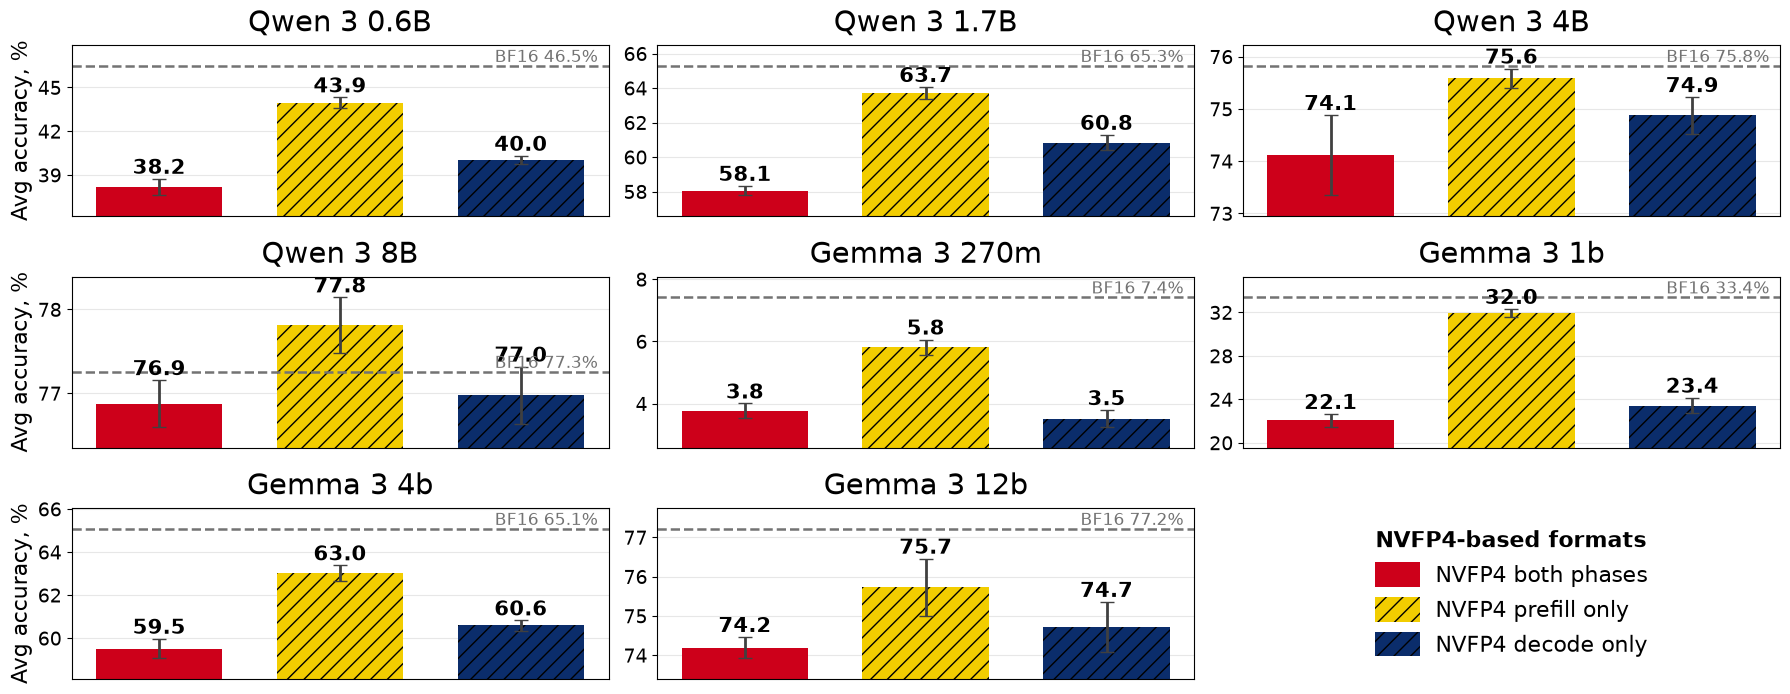

In [215]:
plot_recovery_bars(["nvfp4", "nvfp4prefill", "nvfp4decode"],
                   labels=["NVFP4 both phases", "NVFP4 prefill only",
                           "NVFP4 decode only"],
                   legend_title="NVFP4-based formats",
                   nrows=3, figsize=(18, 7),
                   outfile="figures/bars_phase_isolation.pdf")


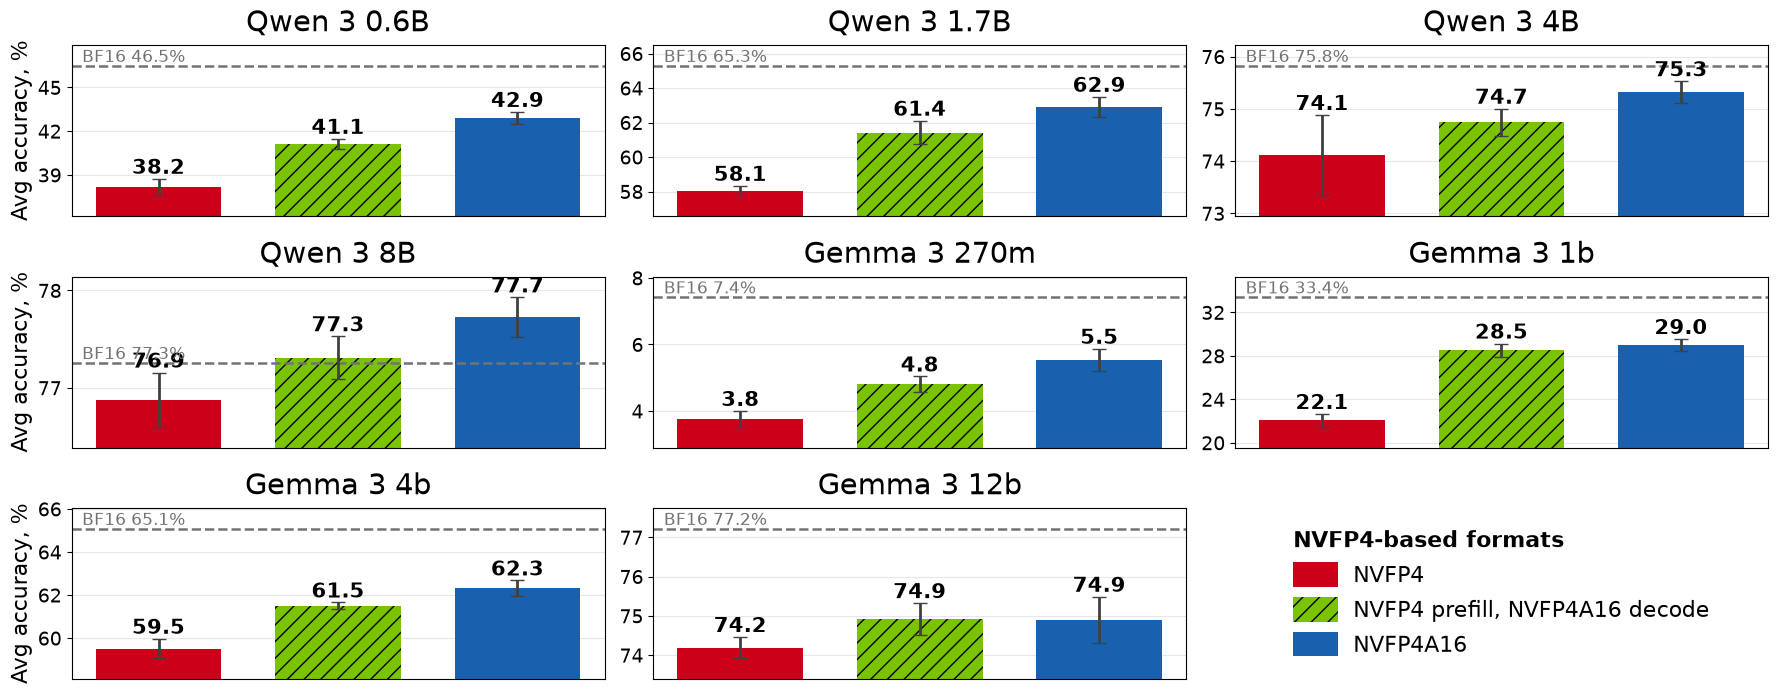

In [216]:
plot_recovery_bars(["nvfp4", "nvfp4pdshared", "nvfp4a16"],
                   labels=["NVFP4", "NVFP4 prefill, NVFP4A16 decode", "NVFP4A16"],
                   method_to_color={
                    "nvfp4": RED,
                    "nvfp4pdshared": GREEN,
                    "nvfp4a16": BLUE,
                   },
                   hline_annot_left=True,
                   legend_title="NVFP4-based formats",
                   nrows=3, figsize=(18, 7),
                   outfile="figures/bars_disable.pdf")


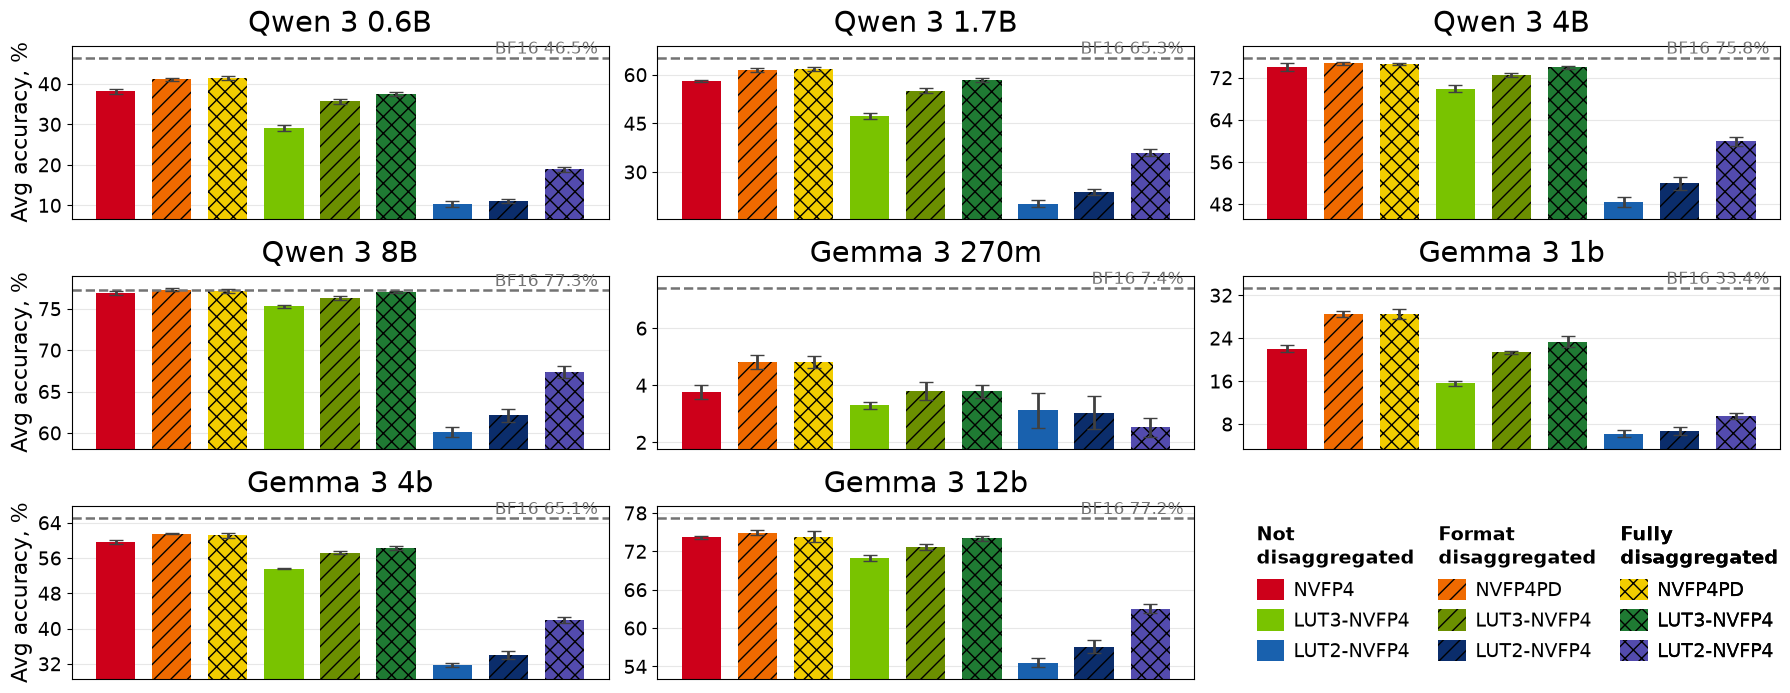

In [217]:
plot_recovery_bars([
        "nvfp4", "nvfp4pdshared", "nvfp4pdsplit",
        "nvfp4lloyd43upcastboth", "nvfp4lloyd43upcast", "nvfp4lloyd43split",
        "nvfp4lloyd21upcastboth", "nvfp4lloyd21upcast", "nvfp4lloyd21split",
    ],
    group_legend=True, annotate=False, nrows=3, figsize=(18, 7),
    outfile="figures/bars_disag.pdf")


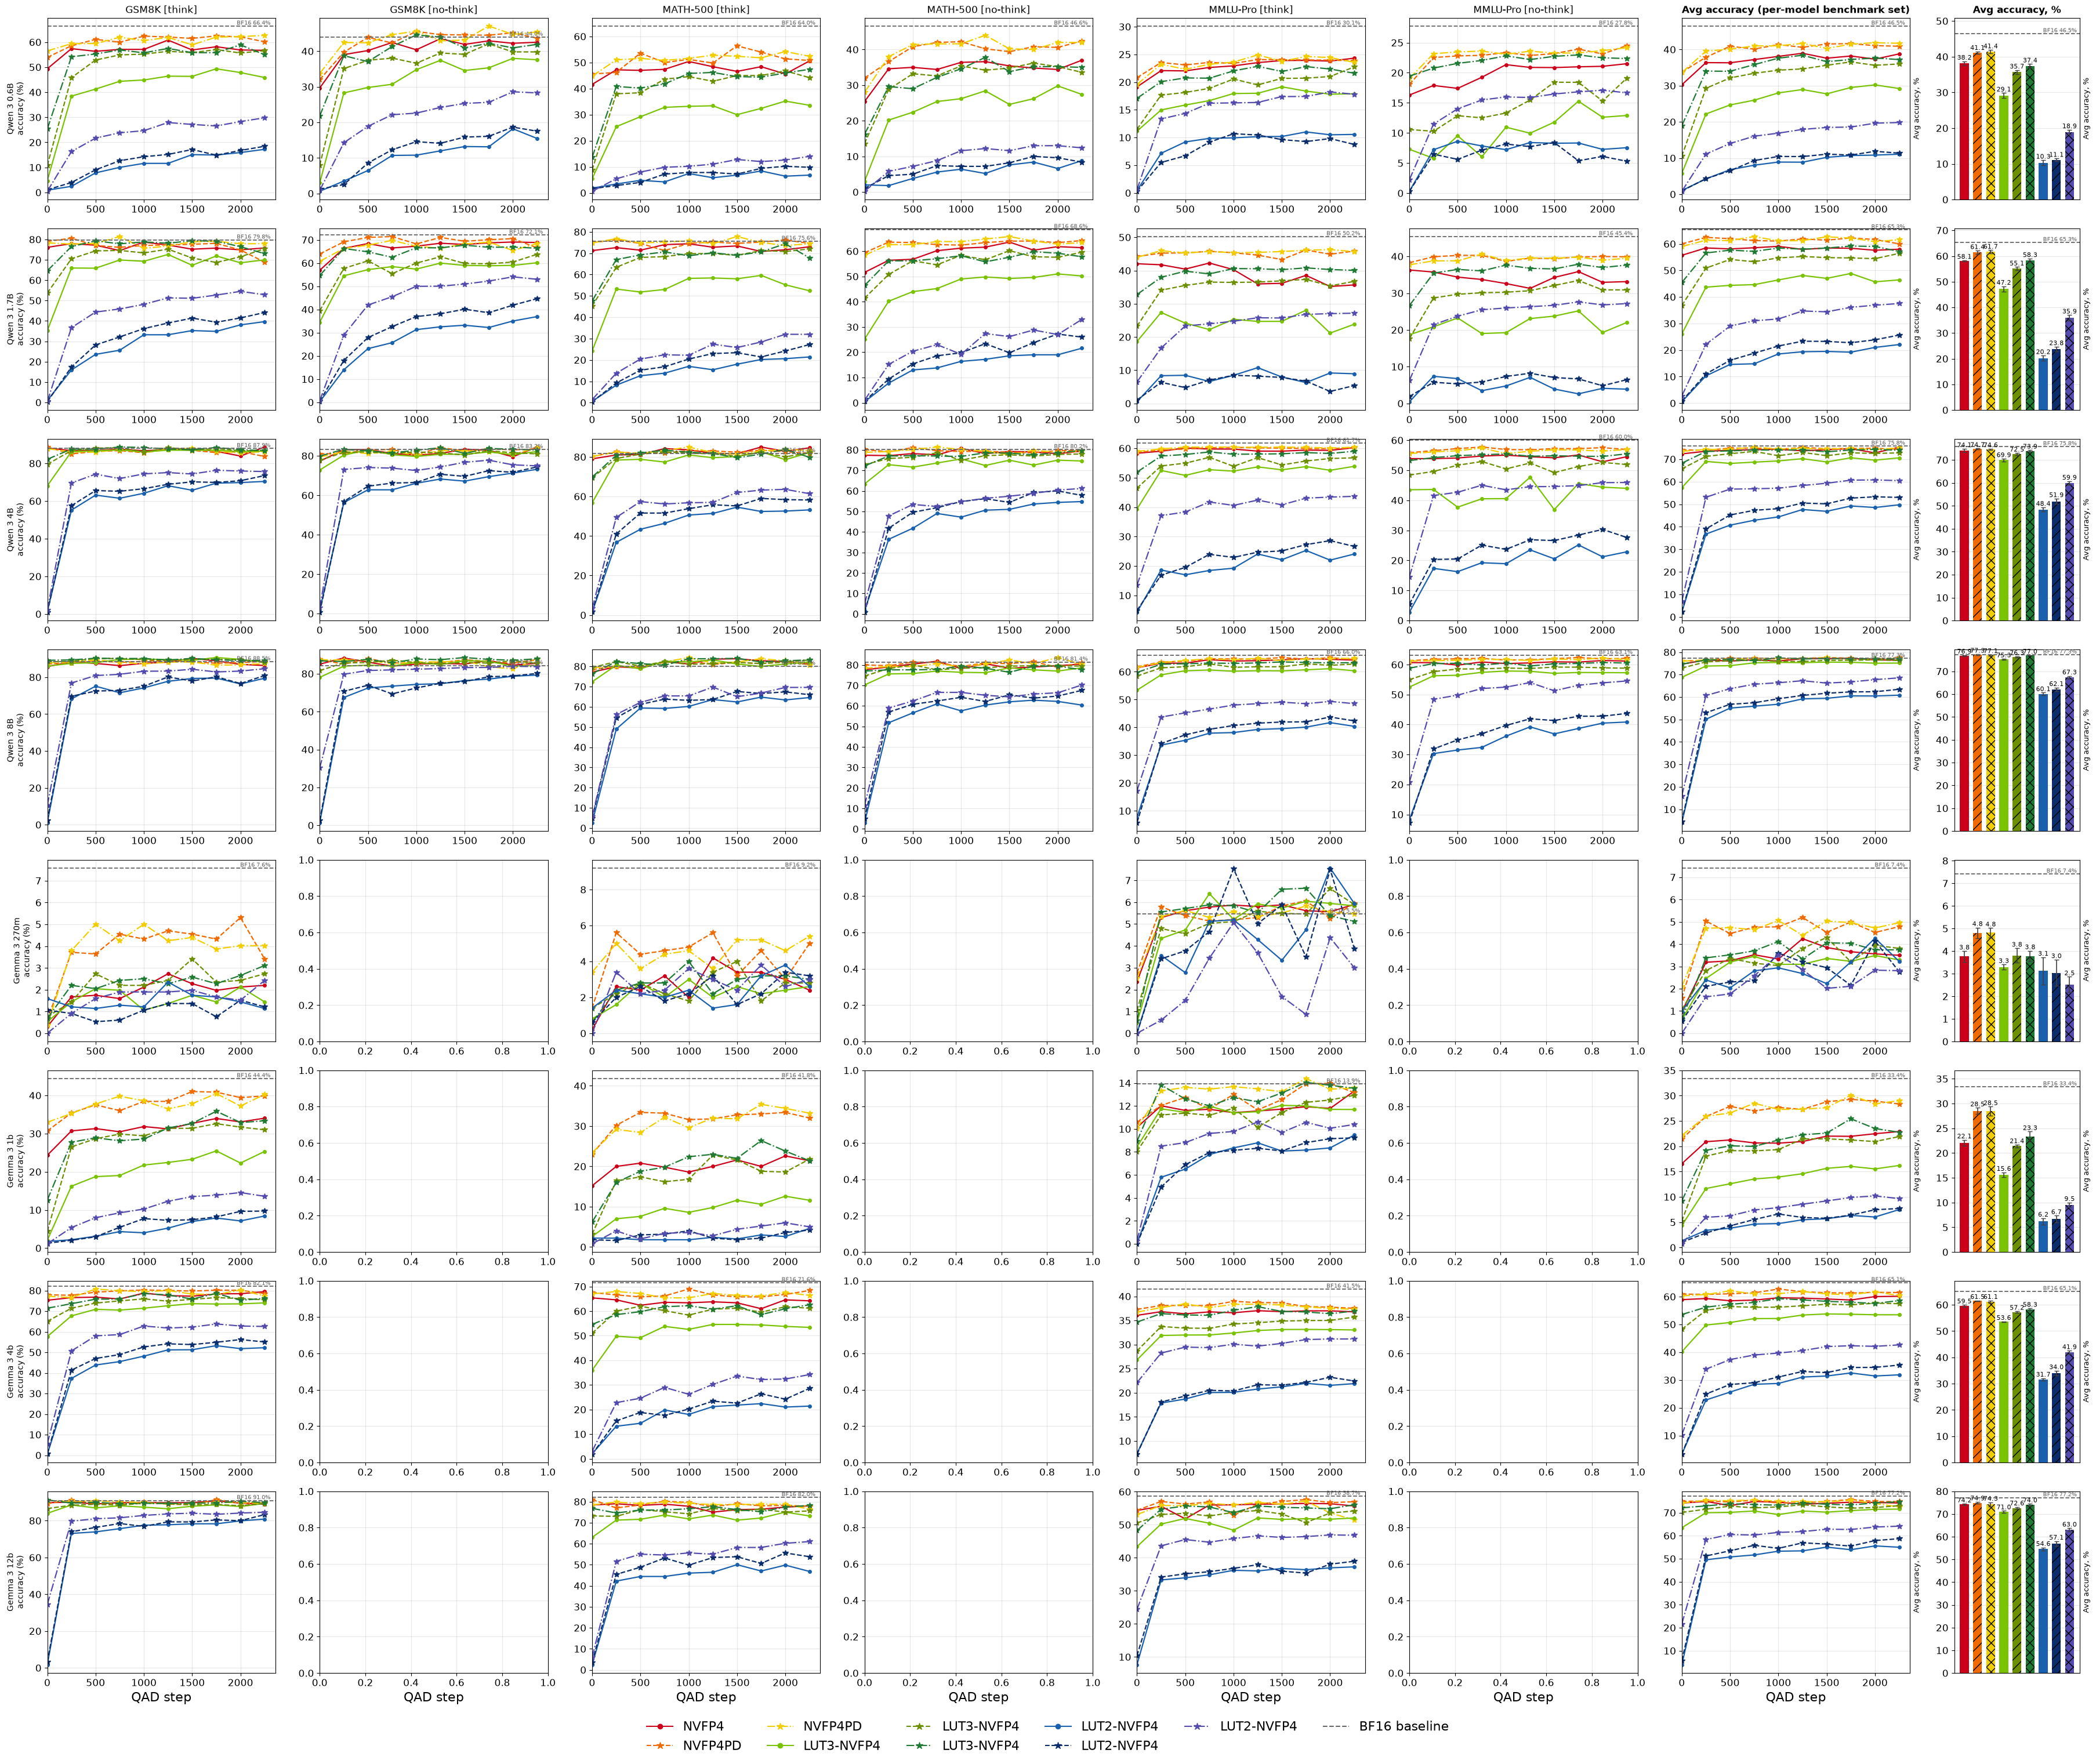

note: Qwen 3 0.6B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 1.7B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen 3 4B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])


In [218]:
plot_grid([
        "nvfp4", "nvfp4pdshared", "nvfp4pdsplit",
        "nvfp4lloyd43upcastboth", "nvfp4lloyd43upcast", "nvfp4lloyd43split",
        "nvfp4lloyd21upcastboth", "nvfp4lloyd21upcast", "nvfp4lloyd21split",
    ],
    group_legend=True,
    outfile="figures/lines_disag.pdf")

In [ ]:
plot_grid(["nvfp4", "nvfp4prefill", "nvfp4decode"],
          labels=["NVFP4 both phases", "NVFP4 prefill only", "NVFP4 decode only"],
          legend_title="NVFP4-based formats",
          outfile="figures/lines_phase_isolation.pdf")


In [ ]:
plot_grid(["nvfp4", "nvfp4pdshared", "nvfp4a16"],
          labels=["NVFP4", "NVFP4 prefill, A16 decode", "NVFP4A16"],
          legend_title="NVFP4-based formats",
          outfile="figures/lines_disable.pdf")


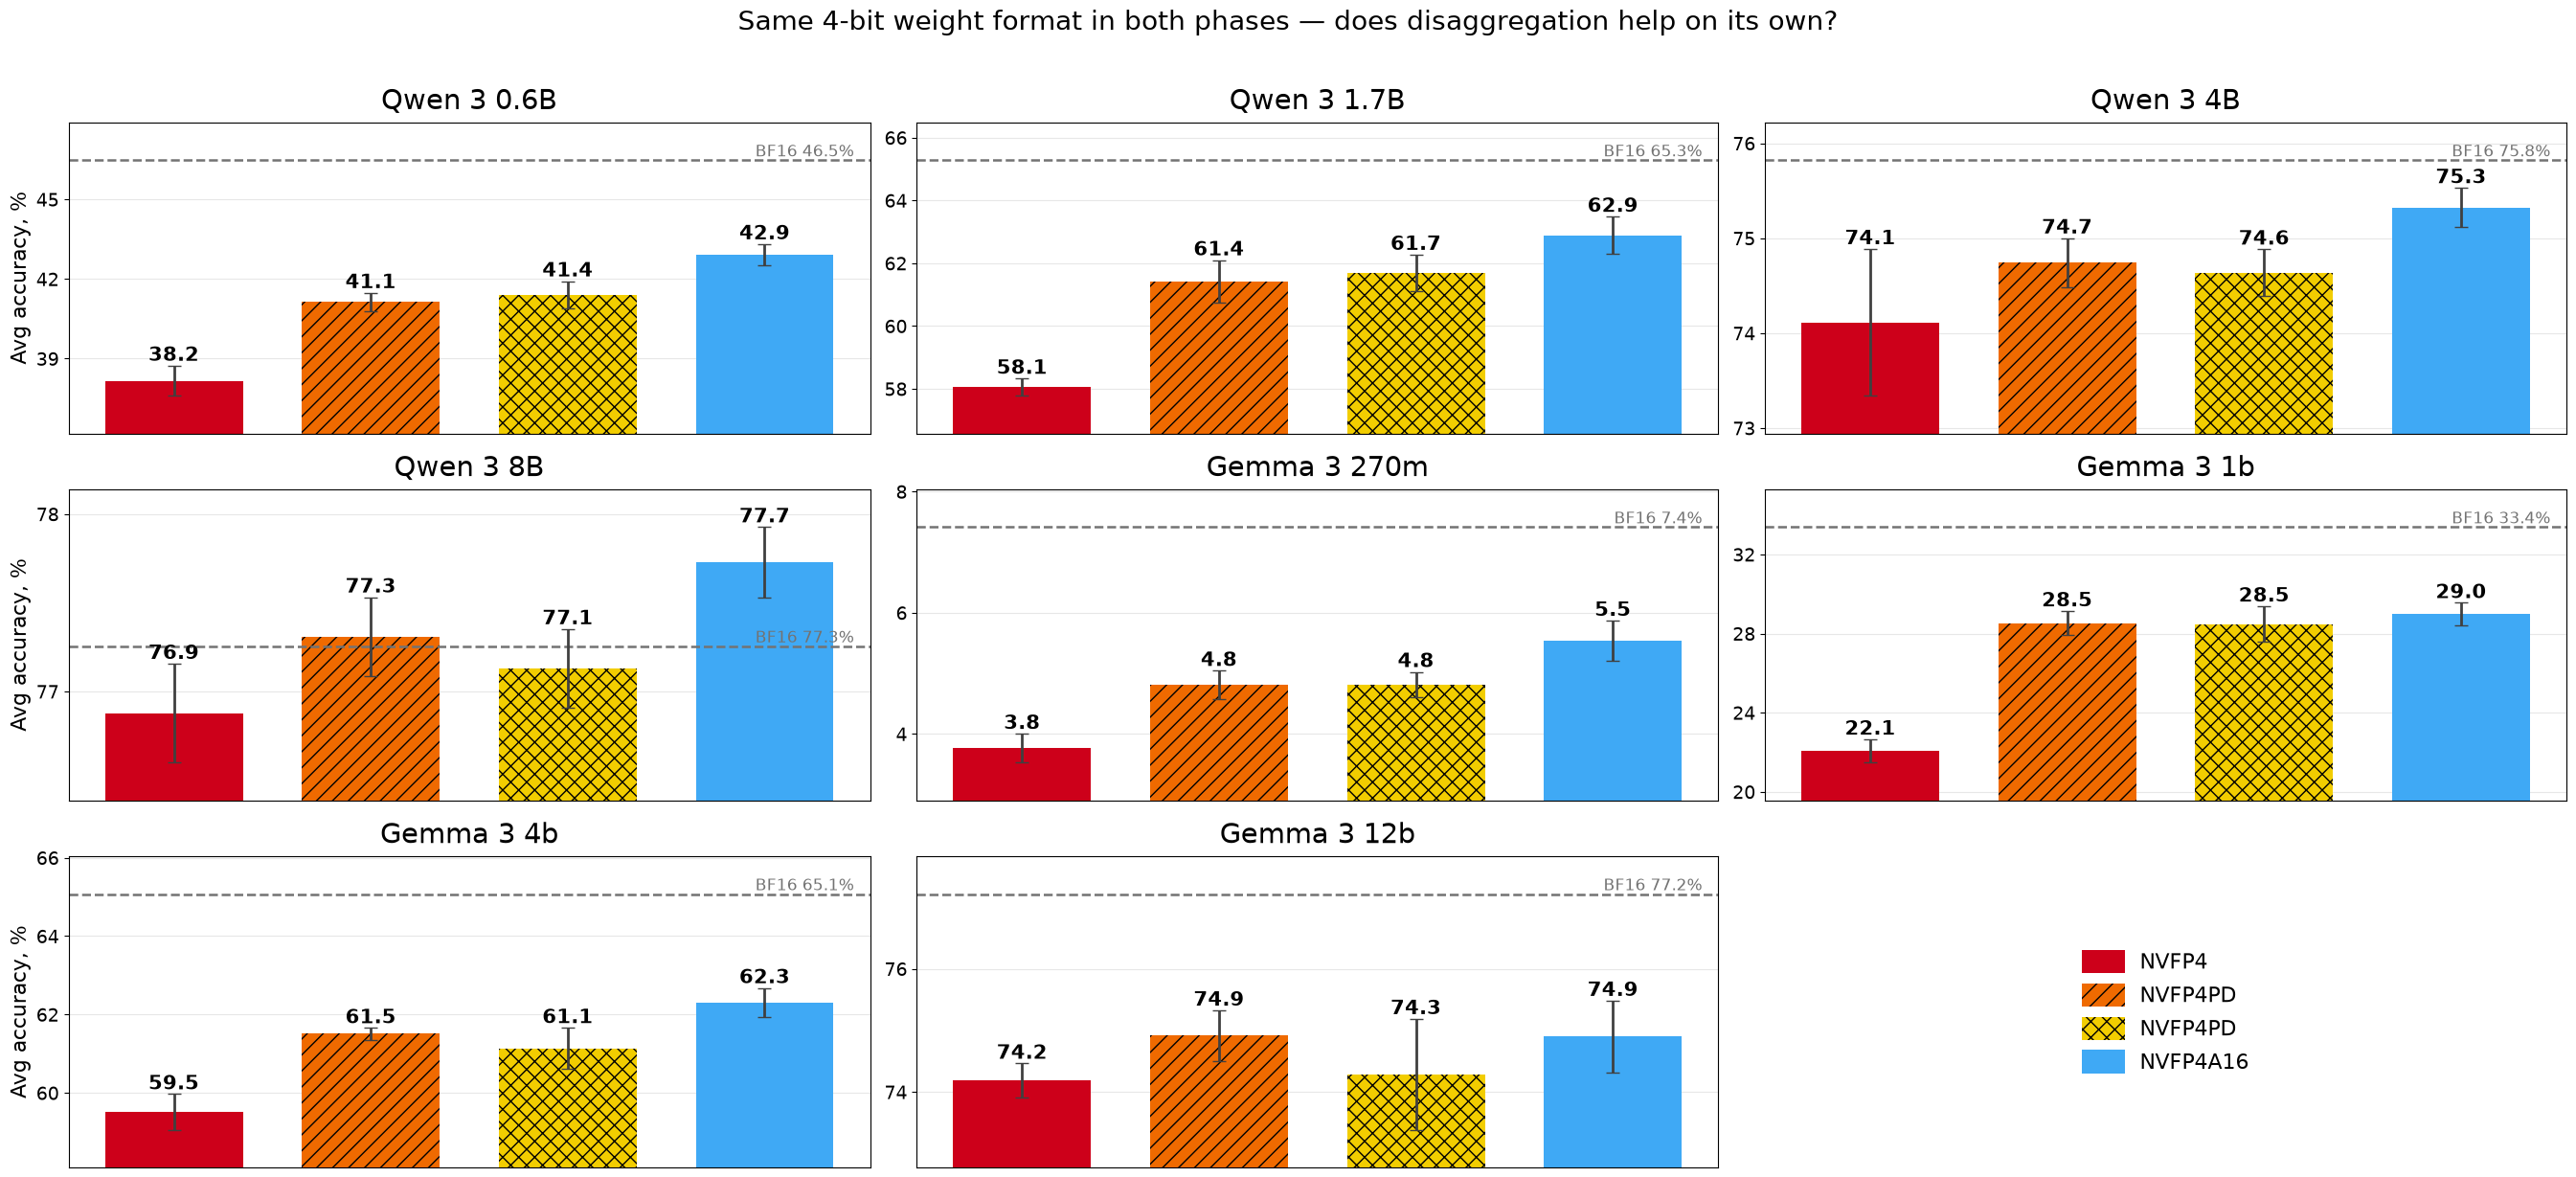

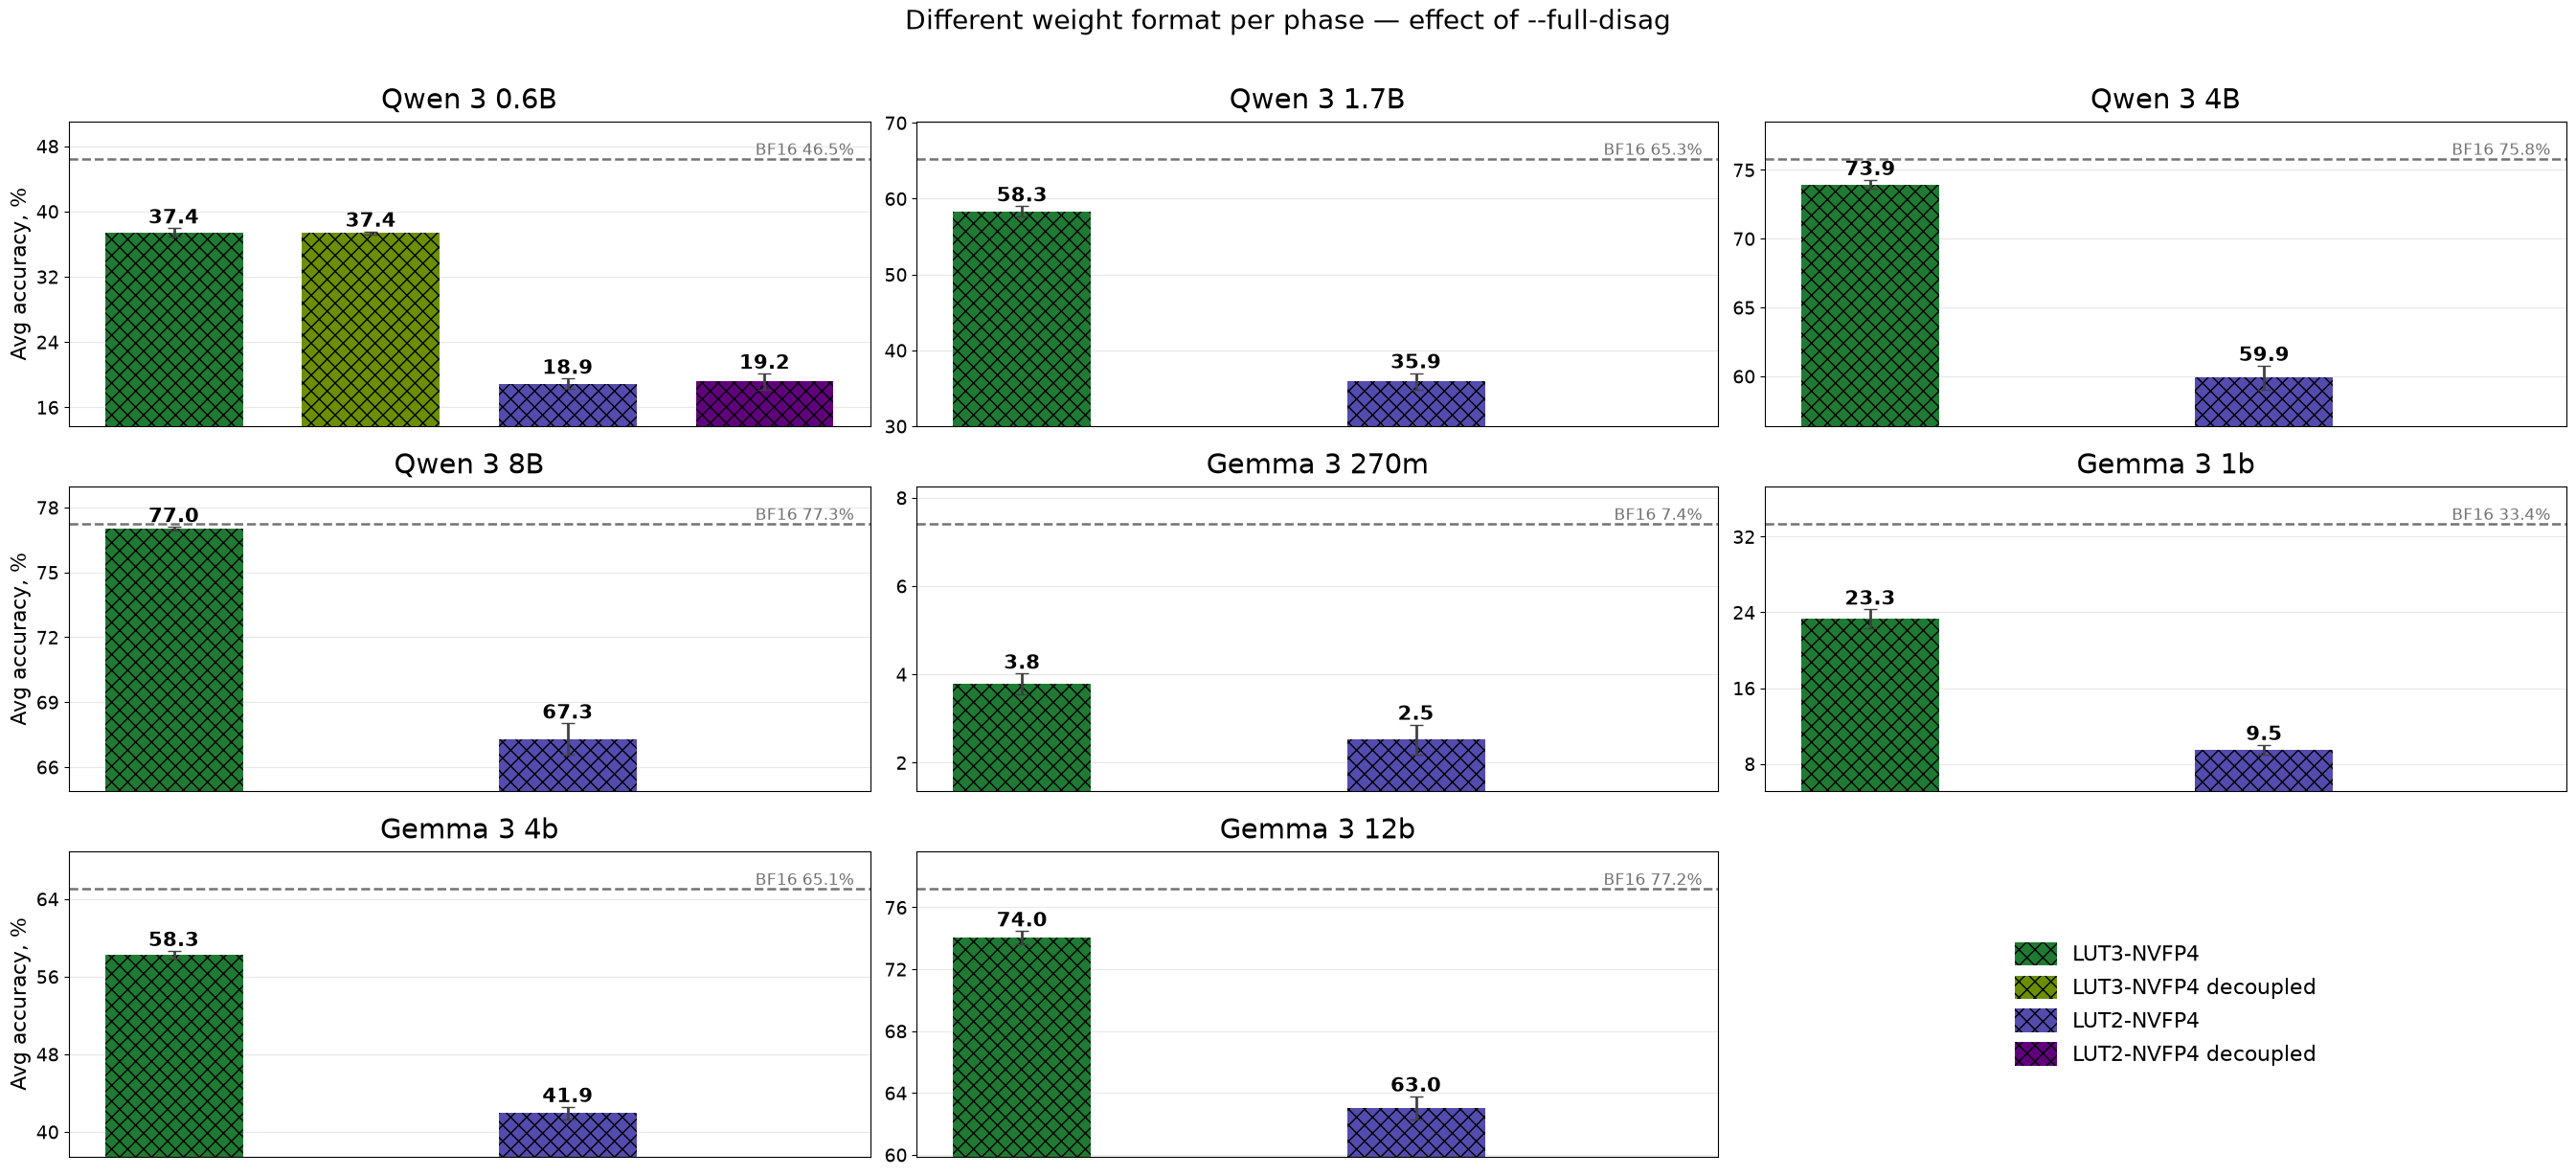

In [219]:
# DISAGGREGATION ABLATION -- two questions, same bar figure as every other slide.
#
# (1) SAME weight format in both phases. Every arm below stores 4-bit NVFP4 weights on both
#     sides, so disaggregation cannot be buying a bitwidth difference: the only thing it
#     changes is that the decode half stops quantizing ACTIVATIONS (W4A4 -> W4A16), and the
#     split arm additionally gives each phase its own master. This is the control for "is
#     disag worth anything when prefill is not higher precision". nvfp4 and nvfp4a16 bracket
#     it -- always quantize activations, never quantize them -- so if the disag arms land on
#     nvfp4a16 the win is the activation precision, not the disaggregation.
plot_recovery_bars(["nvfp4", "nvfp4pdshared", "nvfp4pdsplit", "nvfp4a16"], nrows=3,
                   suptitle="Same 4-bit weight format in both phases — "
                            "does disaggregation help on its own?")

# (2) DIFFERENT weight format per phase, and whether --full-disag adds anything on top.
#     Each pair keeps its plain arm's colour (colour = decode-side precision, which the flag
#     does not change) and differs by hatch: // = disaggregated linears, xx = also dual
#     embedding, norms and LM head.
plot_recovery_bars([
    "nvfp4lloyd43split", "nvfp4lloyd43split-a9264ff4",
    "nvfp4lloyd21split", "nvfp4lloyd21split-a9264ff4",
    ],nrows=3,
suptitle="Different weight format per phase — effect of --full-disag")


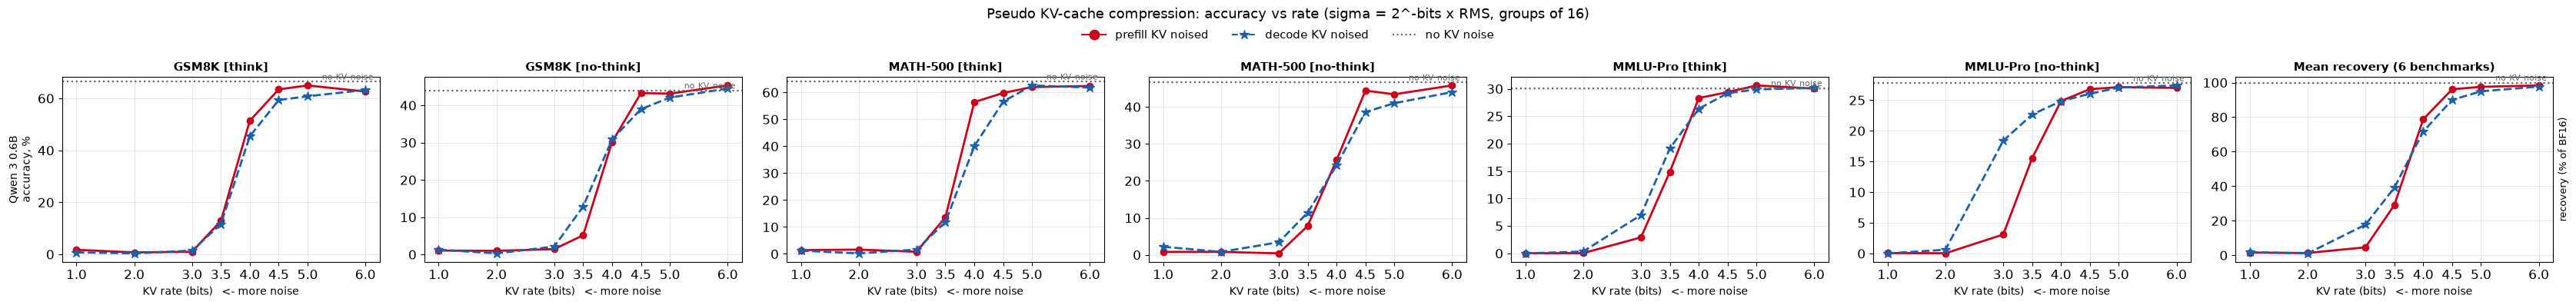

In [224]:
# KV-CACHE COMPRESSION SWEEP: accuracy vs rate, prefill-noise against decode-noise.
#
# Pseudo-compression (qad/kv_noise_connector.py): a token's K/V is degraded ONCE as it is
# written to the paged cache, by N(0, sigma^2) per contiguous group of 16 channels, with
#     sigma = 2^-kv_bits * RMS(group)
# so 4^-kv_bits of distortion POWER -- Shannon's D(R) for a Gaussian source. Lower bits =
# more noise. The right-hand end of each x axis is therefore the *gentle* end.
#
# Two arms, run on ONE BF16 checkpoint, so nothing here is confounded by training:
#   kvP  prefill engine noised, decode untouched  -> cost of compressing PROMPT KV
#   kvD  decode engine noised, prefill untouched  -> cost of compressing GENERATED KV
#
# READ THE ARMS WITH CARE. On these benchmarks prompts are long and generations short, so
# at equal rate the prefill arm degrades far MORE KV entries than the decode arm. A flat
# kvD curve therefore does not by itself show that decode KV is robust -- it may mean
# there was little of it to damage. The comparison is only fair per KV entry.
#
# Note also that the cache stores POST-RoPE keys (qwen3.py applies rotary_emb before
# self.attn writes the cache), so both arms perturb rotated keys -- which is what a real
# KV codec compresses.
import glob as _glob

KV_RE_PLOT = __import__("re").compile(
    r"Qwen3-([0-9.]+B)-unquantized-kv([pd])(\d+(?:\.\d+)?)$")
KV_ARMS = {"p": ("prefill KV noised", RED, "-", "o"),
           "d": ("decode KV noised", BLUE, "--", "*")}


def _load_kv_sweep():
    """{(model, arm, bits, task@mode): accuracy} straight from the results trees.

    Read separately from `models` because these runs are not checkpoints: one BF16 model
    at several rates, tagged ...-kvp<bits> / -kvd<bits>, with no quantizer or step.
    """
    out = {}
    for mode, tree in (("think", "results/disagg/think"),
                       ("nothink", "results/disagg/nothink")):
        for d in _glob.glob(f"../qad/{tree}/*-unquantized-kv*"):
            m = KV_RE_PLOT.search(d.rstrip("/").split("/")[-1])
            if not m:
                continue
            model, arm, bits = f"Qwen-Qwen3-{m.group(1)}", m.group(2), float(m.group(3))
            for f in _glob.glob(f"{d}/step_*.json"):
                try:
                    res = json.load(open(f)).get("results", {})
                except Exception:
                    continue
                for task, (_, key) in BENCHMARKS.items():
                    if task in res and key in res[task]:
                        out[(model, arm, bits, f"{task}@{mode}")] = 100.0 * res[task][key]
    return out


def plot_kv_sweep(outfile=None, scale=1.0):
    """One row per model; columns = benchmarks then mean recovery, x = kv_bits."""
    data = _load_kv_sweep()
    if not data:
        print("no KV-noise results on disk yet (looking for *-unquantized-kv[pd]<bits>)")
        return
    kv_models = sorted({k[0] for k in data}, key=_size)
    panels = tasks + [AVG]
    F = lambda pt: pt * scale
    fig, axes = plt.subplots(len(kv_models), len(panels),
                             figsize=(4.8 * len(panels) * scale, 3.7 * len(kv_models) * scale),
                             squeeze=False)
    for i, model in enumerate(kv_models):
        bl_all = baselines.get(model, {})
        for j, panel in enumerate(panels):
            ax = axes[i][j]
            for arm, (label, color, ls, mk) in KV_ARMS.items():
                bits = sorted({k[2] for k in data if k[0] == model and k[1] == arm})
                xs, ys = [], []
                for b in bits:
                    if panel == AVG:
                        # mean RECOVERY over the benchmarks, same definition as
                        # avg_recovery(): only rates where EVERY benchmark reported.
                        vals = [data.get((model, arm, b, t)) for t in tasks]
                        if any(v is None for v in vals) or not all(bl_all.get(t) for t in tasks):
                            continue
                        ys.append(sum(v / bl_all[t] for v, t in zip(vals, tasks))
                                  / len(tasks) * 100.0)
                    else:
                        v = data.get((model, arm, b, panel))
                        if v is None:
                            continue
                        ys.append(v)
                    xs.append(b)
                if xs:
                    ax.plot(xs, ys, marker=mk, markersize=F(9 if mk == "*" else 6),
                            linestyle=ls, linewidth=F(2.0), color=color, label=label)
            # uncompressed reference: 100% recovery by construction, or the raw baseline
            bl = 100.0 if panel == AVG else bl_all.get(panel)
            if bl is not None:
                ax.axhline(bl, ls=":", color="0.4", linewidth=F(1.6))
                ax.annotate("no KV noise", xy=(0.98, bl), xycoords=("axes fraction", "data"),
                            ha="right", va="bottom", fontsize=F(8), color="0.4")
            if i == 0:
                ax.set_title("Mean recovery (6 benchmarks)" if panel == AVG
                             else TASKS[panel][0], fontweight="bold", fontsize=F(11))
            if j == 0:
                ax.set_ylabel(short_name(model) + "\naccuracy, %", fontsize=F(10))
            if panel == AVG:
                ax.set_ylabel("recovery (% of BF16)", fontsize=F(9))
                ax.yaxis.set_label_position("right")
            if i == len(kv_models) - 1:
                ax.set_xlabel("KV rate (bits)   <- more noise", fontsize=F(10))
            ax.set_xticks(sorted({k[2] for k in data if k[0] == model}))
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
    handles = [plt.Line2D([], [], color=c, ls=ls, marker=mk, markersize=F(9), label=lab)
               for lab, c, ls, mk in KV_ARMS.values()]
    handles.append(plt.Line2D([], [], color="0.4", ls=":", label="no KV noise"))
    fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=F(11),
               frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Pseudo KV-cache compression: accuracy vs rate "
                 "(sigma = 2^-bits x RMS, groups of 16)", fontsize=F(13), y=1.06)
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()


plot_kv_sweep()


# Sweep progress & ETA

Reads SLURM plus the eval logs on disk and reports, per running job, **which stage of
the pipeline it is in** and how far through generation it is — then an ETA for the
whole sweep.

Stages come from markers the driver prints, so "no output" is never mistaken for
"stalled": lm-eval is silent for the whole generation phase, which is most of a job's
life. Progress inside that phase is read from the proxy's completed-request count
instead.

ETA uses the *observed* median runtime of already-COMPLETED jobs of the same kind
rather than a guess, and adds a queue-drain term for PENDING jobs based on how many can
run at once.


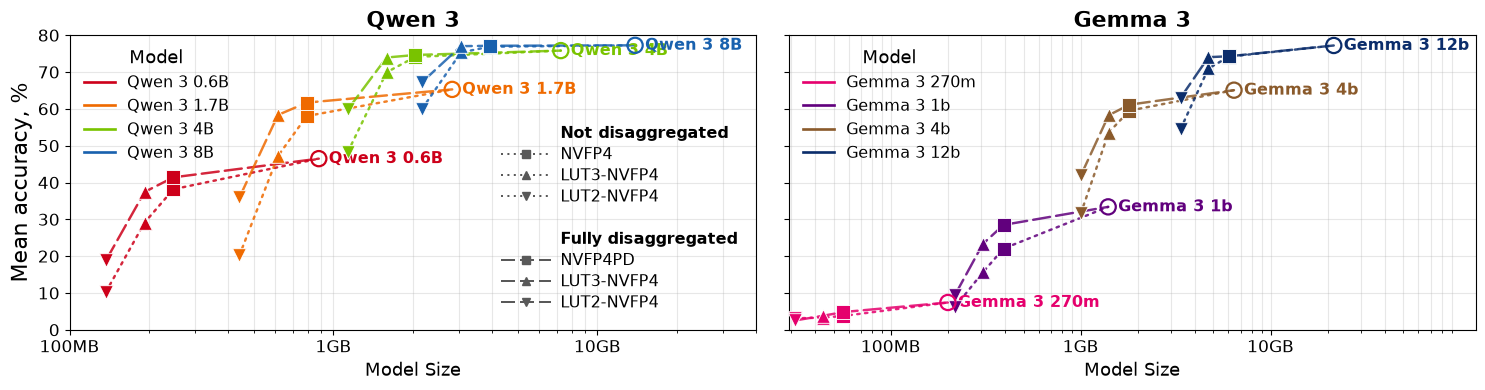

In [225]:
# PARETO: decode-side weight footprint vs accuracy.
#
# The question every one of these formats is really answering: for a given number of
# GIGABYTES you must hold resident to decode, how much accuracy do you get? Decode is the
# memory-bound phase, so its weight footprint is the deployment cost -- and a 2-bit 8B may
# beat a 4-bit 4B at the same size, which is invisible in any per-model figure.
#
# EXCLUDES embeddings and lm_head, which are not quantized by any of these formats (they
# would add a constant to every point and compress the interesting differences). Sizes are
# the DECODE half only; the prefill checkpoint is a separate residency question.
#
# HONESTY ABOUT THE X AXIS. This is the size a deployable kernel WOULD use, not the size on
# disk: the Lloyd/LUT formats ship pseudo-quantized (bf16 weights, no 2/3-bit kernel
# exists), so their bars are what such a kernel would cost, not what we measured. NVFP4
# numbers are real. Block scales are included at 8 bits per group of 16 (+0.5 bits/weight)
# because a deployed cache pays for them.
import numpy as _np

# Non-embedding linear parameters, from each config: L*(q+k+v+o) + L*3*i*h.
LINEAR_PARAMS = {"Qwen-Qwen3-0.6B": 0.440e9, "Qwen-Qwen3-1.7B": 1.409e9,
                 "Qwen-Qwen3-4B":   3.633e9, "Qwen-Qwen3-8B":   6.946e9,
                 # Gemma-3, same formula: L*(q+k+v+o) + L*3*i*h, head_dim 256 at every
                 # size. Text stack only -- the 4b/12b vision tower is neither trained nor
                 # exported, so counting it would inflate the x axis by ~0.4B/~1.2B.
                 "google-gemma-3-270m-it":  0.100e9, "google-gemma-3-1b-it":   0.698e9,
                 "google-gemma-3-4b-it":    3.209e9, "google-gemma-3-12b-it": 10.758e9}

# Bits per weight the DECODE half stores. The prefill half may differ -- that is the whole
# point of the disaggregated formats -- and is deliberately not counted here.
DECODE_BITS = {
    "nvfp4": 4, "nvfp4lloyd43upcastboth": 3, "nvfp4lloyd21upcastboth": 2,
    # "nvfp4lloyd21upcast": 2, "nvfp4lloyd43upcast": 3, "nvfp4pdshared": 4,
    "nvfp4lloyd21split": 2, "nvfp4lloyd43split": 3, "nvfp4pdsplit": 4,
}
SCALE_BITS_PER_WEIGHT = 8 / 16       # one FP8 block scale per 16 weights


def decode_gb(model, method):
    bits = DECODE_BITS[method] + (SCALE_BITS_PER_WEIGHT if DECODE_BITS[method] < 16 else 0)
    return LINEAR_PARAMS[model] * bits / 8 / 1e9


def tail_accuracy(model, method, task_subset=None, models_src=None, baselines_src=None):
    """Mean RAW accuracy over the given tasks (defaults to all plotted tasks), last-5 steps.

    Raw accuracy, not recovery, because the y axis has to be comparable ACROSS models --
    recovery is normalised per model and would put every model's BF16 at 100%, hiding
    exactly the size/quality trade this figure exists to show.
    """
    # Defaults to the columns THIS model can have, not the global list: with a
    # think-only family in the grid, defaulting to `tasks` makes every Gemma point
    # return None and the family vanishes from the Pareto without a warning.
    _tasks = task_subset if task_subset is not None else tasks_for(model)
    _msrc = models_src if models_src is not None else models
    vals = []
    for t in _tasks:
        curve = _msrc.get(model, {}).get(method, {}).get(t)
        if not curve:
            return None
        steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0][-TAIL_N:]
        if not steps:
            return None
        # NOT *100: the loader already stores accuracy in percent (baselines are
        # 66.4, not 0.664), and double-scaling put the quantized points at ~6000%
        # while the BF16 references collapsed onto the axis.
        vals.append(sum(curve[s] for s in steps) / len(steps))
    return sum(vals) / len(vals)


# Colour now identifies the MODEL and marker identifies the FORMAT, which is the pairing
# this figure needs: the question is whether a compressed big model beats an uncompressed
# small one, so the eye has to group by model first. That is the opposite of the per-model
# figures, where colour is the method -- deliberately, because there every panel IS one
# model and colour is free to carry the format.
MODEL_COLOUR = {"Qwen-Qwen3-0.6B": RED, "Qwen-Qwen3-1.7B": ORANGE,
                "Qwen-Qwen3-4B": GREEN, "Qwen-Qwen3-8B": BLUE,
                "google-gemma-3-270m-it": PINK, "google-gemma-3-1b-it": PURPLE,
                "google-gemma-3-4b-it": BROWN, "google-gemma-3-12b-it": NAVY}
# Distinct shapes, ordered so the families read together: circles = homogeneous,
# triangles/diamonds = duals, squares = LUT.
# MARKER = DECODE BIT-WIDTH, LINESTYLE = FAMILY. The two axes of this figure are "how
# small is the decode weight" and "how did you get there", so each visual channel carries
# exactly one of them. Same-bitwidth formats therefore share a marker: LUT2, NVFP4/LUT2
# and NVFP4+LUT2 are all triangles, and it is the line through them that says which
# family they belong to.
BITS_MARKER = {2: "v", 3: "^", 4: "s"}


def _marker(method):
    if method in REFERENCE:
        return "o"                       # the reference is deliberately its own shape
    return BITS_MARKER.get(DECODE_BITS.get(method), "o")


# Straight off the shared DISAG table: these chains and the bar legend's sections are the
# same three groups, and a local copy of the mapping is how they would drift apart.
def _family(method):
    return DISAG.get(method)


# Dash patterns are explicit and widely spaced: the default "--" and ":" are hard to
# tell apart at print size under the alpha these chains are drawn with.
FAMILY_LS = {"none":   (0, (1, 2.2)),      # fine dots
             "format": "solid",
             "full":   (0, (7, 2.5))}           # long dashes
# Drawn in black at reduced size, outside all families and both colour keys.
REFERENCE = {}

# Panels that omit the (panel-invariant) format legend. Add a family here to reclaim the
# space; the per-panel MODEL legend is always drawn.
NO_FORMAT_LEGEND = {"gemma3"}

def plot_pareto(methods=None, outfile=None, scale=1.0, annotate_bf16=True,
               task_subset=None, models_src=None, baselines_src=None):
    """Pareto of decode memory vs accuracy.

    task_subset: list of task keys (e.g. ["minerva_math500@think"]) to use instead of
        the full `tasks` list. Defaults to all plotted tasks.
    """
    # Left as None so tail_accuracy() can resolve it PER MODEL (see there).
    _tasks = task_subset
    _msrc = models_src if models_src is not None else models
    _bsrc = baselines_src if baselines_src is not None else baselines
    methods = [m for m in (methods or PLOT_METHODS) if m in found and m in DECODE_BITS]
    F = lambda pt: pt * scale
    # ONE SUBPLOT PER MODEL FAMILY, side by side. Qwen3 and Gemma-3 share neither axis,
    # deliberately: their accuracy ranges barely overlap (gemma-3-270m sits near the floor
    # while Qwen3-8B is near the top) and their decode footprints differ by an order of
    # magnitude, so a shared axis squeezes both families into unreadable corners. A shared
    # axis would also imply the two are directly comparable, and they are not -- the
    # Average is over a per-family task set (Gemma is think-only), so the plotted y
    # quantity itself differs between panels. Each panel therefore carries its own full
    # legend instead of one figure-level legend.
    mfams = [f for f in ("qad3x", "gemma3")
             if any(family_of(m) == f and m in LINEAR_PARAMS for m in PARETO_ORDER)]
    fig, axes = plt.subplots(1, len(mfams), figsize=(9.5 * len(mfams) * scale, 5.0 * scale),
                             squeeze=False, sharex=False, sharey=True)
    axes = axes[0]

    for ax, mfam in zip(axes, mfams):
        for model in PARETO_ORDER:
            if family_of(model) != mfam:
                continue
            if model not in LINEAR_PARAMS:
                continue
            # Resolve the task set PER MODEL. A single global list makes every point of a
            # think-only family return None AND drops its BF16 anchor, so the family would
            # silently disappear from the Pareto rather than plot short.
            _mtasks = _tasks if _tasks is not None else tasks_for(model)
            colour = MODEL_COLOUR.get(model, "0.4")
            short = short_name(model)
            chains = {fam: [] for fam in FAMILY_LS}
            for method in methods:
                acc = tail_accuracy(model, method, _mtasks, models_src=_msrc)
                if acc is None:
                    continue
                x = decode_gb(model, method)
                fam = _family(method)
                if fam:
                    chains[fam].append((x, acc))
                if method in REFERENCE:
                    ax.scatter([x], [acc], s=F(34), c="black", marker="o", zorder=5)
                else:
                    ax.scatter([x], [acc], s=F(120), c=colour,
                               marker=_marker(method),
                               edgecolors="white", linewidths=F(0.8), zorder=3)
            bl = _bsrc.get(model, {})
            if annotate_bf16 and all(bl.get(t) for t in _mtasks):
                xb = LINEAR_PARAMS[model] * 16 / 8 / 1e9
                yb = sum(bl[t] for t in _mtasks) / len(_mtasks)
                # BF16 anchors BOTH chains: it is the uncompressed origin of each family.
                for c in chains.values():
                    c.append((xb, yb))
                ax.scatter([xb], [yb], s=F(150), facecolors="none", edgecolors=colour,
                           linewidths=F(2.0), zorder=4)
                ax.annotate(short, (xb, yb), textcoords="offset points",
                            xytext=(F(9), F(-4)), fontsize=F(14), fontweight="bold",
                            color=colour)
            for fam, chain in chains.items():
                if len(chain) > 1:
                    chain.sort()
                    ax.plot([c[0] for c in chain], [c[1] for c in chain], color=colour,
                            ls=FAMILY_LS[fam], lw=F(2.2), alpha=0.85, zorder=1,
                            solid_capstyle="round", dash_capstyle="round")

        ax.set_xscale("log")
        # Explicit decade ticks in human units. matplotlib's default log labels here are
        # 10^0 / 10^1, which reads as "1" and "10" with no unit and hides that the left half
        # of the figure is in the hundreds of MB.
        if ax == axes[0]:
            ax.set_xlim(0.1, 40.0)
        else:
            ax.set_xlim(0.029, 120.0)
        ax.set_ylim(0, 80)
        ax.set_xticks([0.1, 1.0, 10.0])
        ax.set_xticklabels(["100MB", "1GB", "10GB"])
        ax.xaxis.set_minor_formatter(plt.NullFormatter())
        ax.set_xlabel("Model Size", fontsize=F(16))
        # Y-axis label. `_tasks` is None unless the caller pinned a subset, because the task
        # set is resolved per model above -- so the label must be derived the same way. With
        # more than one family in the figure the rows do NOT average the same number of
        # benchmarks, so only state a count when it is actually uniform rather than quoting
        # one family's count over a mixed figure.
        if _tasks is not None and len(_tasks) == 1:
            task_label = BENCHMARKS[_tasks[0].split("@")[0]][0]
        else:
            _ns = {len(_tasks if _tasks is not None else tasks_for(m))
                   for m in PARETO_ORDER if m in LINEAR_PARAMS}
            task_label = (f"{_ns.pop()} benchmarks" if len(_ns) == 1
                          else "per-model benchmark set")
        if ax == axes[0]:
            ax.set_ylabel(f"Mean accuracy, %", fontsize=F(20))
        ax.grid(True, which="both", alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title({"qad3x": "Qwen 3", "gemma3": "Gemma 3"}[mfam],
                     fontsize=F(20), fontweight="bold")

        # ONE format legend, with the group names as inert rows inside it. Three stacked
        # legends each own their own text column, so the labels never line up with each
        # other; a single legend has one handle column and one text column, which is what
        # makes the entries align horizontally. The group headers are handles with no marker
        # and no line -- they occupy the handle column invisibly and read as section titles.
        def _handle(q):
            if q is None:
                return plt.Line2D([], [], color="0.35", ls="none", marker="o",
                                  markerfacecolor="none", markersize=F(8), label="BF16")
            if q in REFERENCE:
                return plt.Line2D([], [], color="black", ls="none", marker="o",
                                  markersize=F(5), label=METHODS[q][0])
            return plt.Line2D([], [], color="0.35", ls=FAMILY_LS.get(_family(q), "none"),
                              lw=F(1.8), marker=_marker(q),
                              markersize=F(8), label=METHODS[q][0])

        def _header(text):
            return plt.Line2D([], [], ls="none", marker="none", label=text)

        groups = [(title, [m for m in methods
                           if _family(m) == key or (key == "none" and m in REFERENCE)])
                  for key, title in DISAG_LABEL.items()]
        handles = []
        for i, (title, qs) in enumerate(groups):
            if not qs:
                continue
            if i:
                handles.append(_header(" "))        # blank row between sections
            handles.append(_header(title))
            handles += [_handle(q) for q in qs]
        # handlelength matters here: the default sample is too short to show a dash pattern,
        # so the upcast (solid) and disaggregated (long-dash) sections looked identical in the
        # legend even though the chains on the figure are clearly different.
        # The format legend is identical in every panel -- same methods, same markers, same
        # linestyles -- so drawing it twice spends a third of each panel restating one key.
        # It is kept on the Qwen3 panel and dropped on Gemma-3, where the curves climb into
        # the lower-right corner the legend occupies. The MODEL legend stays on BOTH,
        # because that one genuinely differs per panel.
        if mfam not in NO_FORMAT_LEGEND:
            leg = ax.legend(handles=handles, fontsize=F(14), frameon=False,
                            loc="lower right", labelspacing=0.35, handletextpad=0.6,
                            borderaxespad=0.8, handlelength=3.2)
            # Bold the section titles so they read as headers, not unmarked entries.
            titles = {t for t, _ in groups}
            for txt in leg.get_texts():
                if txt.get_text() in titles:
                    txt.set_fontweight("bold")
            ax.add_artist(leg)

        colour_handles = [plt.Line2D([], [], color=MODEL_COLOUR[m], ls="-", lw=F(2.4),
                                     label=short_name(m))
                          for m in PARETO_ORDER
                          if m in MODEL_COLOUR and family_of(m) == mfam]
        ax.legend(handles=colour_handles, fontsize=F(14), frameon=False,
                  loc="upper left", title="Model", title_fontsize=F(16))

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()


plot_pareto(scale=0.8, outfile="figures/pareto.pdf")


In [226]:
import json, os, re, subprocess, glob, time
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path("..")
LOGS = ROOT / "logs" / "eval_disagg"
JOB_NAME = "qad-disagg"

def sh(cmd):
    try:
        return subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=60).stdout
    except Exception:
        return ""

def to_min(t):
    """SLURM elapsed (D-HH:MM:SS / HH:MM:SS / MM:SS) -> minutes."""
    if not t or t in ("0:00",): return 0.0
    d, _, rest = t.partition("-")
    if not rest: rest, d = d, "0"
    p = [float(x) for x in rest.split(":")]
    sec = p[-1] + (p[-2] * 60 if len(p) > 1 else 0) + (p[-3] * 3600 if len(p) > 2 else 0)
    return (float(d) * 86400 + sec) / 60

# quantizer slug -> the label used everywhere else (plots, sweep --formats)
QUANT_LABEL = {
    "unquantized": "BF16", "nvfp4a16": "NVFP4A16", "nvfp4pdshared": "NVFP4-pd-shared",
    "nvfp4pdsplit": "NVFP4-pd-split", "lloyd3bit": "W3A16-Lloyd", "nvfp4": "NVFP4",
}
# longest slug first: "nvfp4" is a prefix of "nvfp4a16" and both pd variants
_SLUGS = sorted(QUANT_LABEL, key=len, reverse=True)

# Pseudo KV-cache compression runs (kv_noise_connector.py) tag themselves
# ...-kvp<bits> / ...-kvd<bits>: the rate applied to the PREFILL or the DECODE engine's
# KV cache, where sigma = 2^-bits * RMS(group of 16), i.e. 4^-bits of distortion power.
# The rate is NOT in the driver banner, only in the tag, so it has to be carried
# separately or enrich() below silently relabels every arm as plain "BF16" and the whole
# sweep looks like one repeated baseline.
# \d+(?:\.\d+)? -- fractional rates (3.5, 4.5) are swept too.
KV_RE = re.compile(r"-kv([pd])(\d+(?:\.\d+)?)(?:[-/_]|$)")

def parse_kv(text):
    """'P4' / 'D2' for a KV-noise arm, else '' -- prefill or decode, at that bit rate."""
    m = KV_RE.search(text or "")
    return f"{m.group(1).upper()}{m.group(2)}" if m else ""

def parse_tag(text):
    """(model size, format label) from a log-dir label or a results-tree tag.

    The KV rate is folded INTO the label so the aggregate tables, which key on
    (size, format), keep the arms apart instead of summing them into one row.
    """
    m = re.search(r"Qwen3-([0-9.]+B)", text or "")
    if not m:
        m = re.search(r"gemma-3-([0-9.]+[bm])-it", text or "")
    size = m.group(1) if m else "?"
    kv = parse_kv(text)
    suffix = f"+kv{kv}" if kv else ""
    for slug in _SLUGS:
        if re.search(rf"[-/]{slug}([-/_]|$)", text or ""):
            return size, QUANT_LABEL[slug] + suffix
    return size, ("?" + suffix if suffix else "?")

# ---- 1. what SLURM thinks. StdOut is included because it resolves size/format for
#         PENDING jobs too, which have not written a log line yet ------------------
rows = []
# -r expands array elements. Without it SLURM collapses pending ones into ranges
# ("479272_[3-9]" is ONE line), so a 204-element sweep reports ~30 pending and the
# ETA below comes out ~6x short.
#
# ArrayJobID/ArrayTaskID, NOT JobID: for an array element JobID is a distinct id
# (array 479274 task 2 -> JobID 479313) while the .out file is named 479274_2.out.
# Keying on JobID silently matched nothing, so 33 generating jobs displayed as
# "queued/starting". JobID is still read -- older stack dirs are named after it.
_W = [12, 10, 12, 14, 14, 250]
def _split(line):
    out, pos = [], 0
    for w in _W:
        out.append(line[pos:pos + w].strip()); pos += w
    return out

rows = []
for line in sh(f'squeue -u $(whoami) -h -r -n {JOB_NAME} '
               f'-O "ArrayJobID:12,ArrayTaskID:10,JobID:12,State:14,TimeUsed:14,StdOut:250"').splitlines():
    if not line.strip(): continue
    ajid, atid, jobid, state, elapsed, stdout = _split(line)
    jid = f"{ajid}_{atid}" if atid and atid != "N/A" else ajid
    size, fmt = parse_tag(os.path.basename(os.path.dirname(stdout)))
    rows.append({"id": jid, "array": ajid, "taskid": (atid if atid != "N/A" else "0"),
                 "jobid": jobid, "state": state, "elapsed": elapsed, "size": size, "fmt": fmt,
                 "kv": parse_kv(os.path.basename(os.path.dirname(stdout))),
                 "mode": "?", "step": "?", "task": "?", "tasks_raw": ""})

# ---- 2. stage + exact config of each job, from its own log -----------------------
# ordered most-advanced first; the first marker found wins
STAGES = [
    ("results ->",     "done (writing)"),
    ("lm_eval: tasks", "generating"),
    ("thinking",       "engines up"),
    ("stack ready",    "stack ready"),
    ("starting stack", "engines loading"),
    ("disagg-eval]",   "container up"),
]
log_index = {}
for f in glob.glob(str(LOGS / "*" / "*.out")):
    m = re.match(r"^(\d+)_(\d+)\.out$", os.path.basename(f))
    if m:
        jid = f"{m.group(1)}_{m.group(2)}" if m.group(2) != "4294967294" else m.group(1)
        log_index.setdefault(jid, f)

BANNER = re.compile(r"\[disagg-eval\] model=(\S+?)\s+(?:quantizer=(\S+)\s+iter=(\S+)\s+|UNQUANTIZED \(BF16\)\s+)"
                    r"think=(\d)\s+tasks=(.+)")

def enrich(r):
    """Fill stage/mode/step/task from the driver banner -- authoritative, unlike the dir name."""
    f = log_index.get(r["id"])
    if not f:
        r["stage"] = "queued/starting"; return r
    try: txt = open(f, errors="ignore").read()
    except OSError:
        r["stage"] = "?"; return r
    if (m := BANNER.search(txt)):
        model, quant, it, think, tasks = m.groups()
        r["size"], _ = parse_tag(model)
        # The banner is authoritative for size/format but knows nothing about the KV
        # rate, so re-attach it from the log-dir name; otherwise every kvp/kvd arm is
        # relabelled "BF16" here and 40 distinct runs collapse into one row.
        r["fmt"] = (QUANT_LABEL.get(quant, quant) if quant else "BF16") + (
            f"+kv{r['kv']}" if r.get("kv") else "")
        r["step"] = it or "0"
        r["mode"] = "think" if think == "1" else "nothink"
        r["tasks_raw"] = tasks.strip()
        r["task"] = r["tasks_raw"].replace("mmlu_flan_cot_zeroshot", "mmlu_cot")
    r["stage"] = next((name for marker, name in STAGES if marker in txt), "container up")
    return r

rows = [enrich(r) for r in rows]
running = [r for r in rows if r["state"] == "RUNNING"]
pending = [r for r in rows if r["state"] != "RUNNING"]

# ---- 3. live generation progress, from the proxy's completed-request count --------
# lm-eval prints NOTHING between "tasks" and its final score, so the per-job median is
# the only ETA available without this: a job 90% done and one 10% done look identical.
# The proxy logs one "prefill ok" per request, which is the one live counter there is.
#
# It measures the PREFILL side, which runs ahead of decode by up to the in-flight window
# (~512 at the current concurrency). So it is a slight over-estimate -- worst case ~4% on
# mmlu_pro -- and it saturates at 100% while the last decodes drain. Treat it as a
# leading indicator, not a completion signal.
TASK_DOCS = {"gsm8k": 1319, "minerva_math500": 500, "aime25": 30,
             "mmlu_pro": 12032, "mmlu_flan_cot_zeroshot": 1531}

def expected_docs(tasks_raw):
    n = sum(TASK_DOCS.get(t, 0) for t in (tasks_raw or "").split())
    return n or None

def proxy_done(r):
    """Requests prefilled so far, or None if this job has no proxy log yet.

    Two namings are tried: the stack dir is now keyed on ARRAY_JOB_ID so it matches
    the .out basename, but jobs launched before that fix are keyed on the element id.
    """
    for base in (r["array"], r["jobid"]):
        try:
            with open(LOGS / f"stack_{base}_{r['taskid']}" / "proxy.log", errors="ignore") as fh:
                return sum(1 for ln in fh if "prefill ok" in ln)
        except OSError:
            continue
    return None

def lmeval_progress(jid):
    """(done, total, timeouts) from lm-eval's own tqdm bar on stderr.

    Strictly better than counting proxy lines: tqdm counts DOCUMENTS, while the proxy
    counts REQUESTS, and a retried request is a second request for the same document.
    With timeouts running at 20-35% that gap is what pushed the bar past 100%.
    """
    f = log_index.get(jid)
    if not f: return None, None, 0
    try:
        with open(f[:-4] + ".err", "rb") as fh:              # tail only; these get large
            fh.seek(0, 2); fh.seek(max(0, fh.tell() - 262144))
            txt = fh.read().decode("utf-8", "replace")
    except OSError:
        return None, None, 0
    # Anchor on the "Requesting API" bar. lm-eval runs a preprocessing tqdm FIRST that
    # completes in seconds, so an unanchored N/M match reads that one and reports a job
    # 8 minutes in as 100% done -- with the bar hitting the top before generation starts.
    m = re.findall(r"Requesting API.*?(\d+)/(\d+) \[", txt.replace("\r", "\n"))
    done, total = (int(m[-1][0]), int(m[-1][1])) if m else (None, None)
    return done, total, txt.count("TimeoutError")

def bar(frac, width=14):
    filled = int(round(min(max(frac, 0.0), 1.0) * width))
    return "[" + "#" * filled + "-" * (width - filled) + "]"

for r in rows:
    if r["state"] != "RUNNING":
        r["done"] = r["total"] = r["frac"] = None; r["timeouts"] = 0
        continue
    done, total, r["timeouts"] = lmeval_progress(r["id"])
    if done is None:                        # no tqdm line yet -> fall back to the proxy
        done, total = proxy_done(r), expected_docs(r["tasks_raw"])
    r["done"], r["total"] = done, total
    r["frac"] = (done / total) if (done and total) else None

# ---- 3. ETA from OBSERVED runtimes of finished jobs ------------------------------
done_min = []
for line in sh('sacct -S now-12hours -u $(whoami) -n --format=JobID,JobName,State,Elapsed -P').splitlines():
    f = line.split("|")
    if len(f) == 4 and JOB_NAME in f[1] and f[2] == "COMPLETED" and re.match(r"^\d+(_\d+)?$", f[0]):
        done_min.append(to_min(f[3]))
done_min.sort()
median = done_min[len(done_min) // 2] if done_min else None

print("jobs: " + (", ".join(f"{k}={v}" for k, v in sorted(Counter(r["state"] for r in rows).items())) or "none queued"))
if median:
    print(f"observed median job runtime: {median:.0f} min  (n={len(done_min)} completed in last 12h)")
else:
    print("no completed jobs yet — ETA unavailable until the first one finishes")

# ---- 4. queue broken down by model size and format -------------------------------
if rows:
    q = defaultdict(lambda: [0, 0])
    for r in rows: q[(r["size"], r["fmt"])][0 if r["state"] == "RUNNING" else 1] += 1
    print(f"\nqueue by model / format:\n  {'size':6} {'format':19} {'run':>4} {'pend':>5}")
    for (size, fmt), (nr, np_) in sorted(q.items()):
        print(f"  {size:6} {fmt:19} {nr:4d} {np_:5d}")

# ---- 5. results already on disk, by size / format / thinking mode ----------------
disk = defaultdict(Counter)
for f in glob.glob(str(ROOT / "qad" / "results" / "disagg" / "*" / "*" / "step_*.json")):
    tree = Path(f).parts[-3]
    size, fmt = parse_tag(Path(f).parts[-2])
    disk[(size, fmt)]["think" if tree.endswith("_think") else "nothink"] += 1
if disk:
    print(f"\nresults on disk:\n  {'size':6} {'format':19} {'think':>6} {'nothink':>8}")
    for (size, fmt), c in sorted(disk.items()):
        print(f"  {size:6} {fmt:19} {c['think']:6d} {c['nothink']:8d}")
    print(f"  {'':6} {'TOTAL':17} {sum(c['think'] for c in disk.values()):6d} "
          f"{sum(c['nothink'] for c in disk.values()):8d}")
else:
    print("\nresults on disk: none yet")

# ---- 6. the running jobs themselves ----------------------------------------------
if running:
    print("\nstage tally:", dict(Counter(r["stage"] for r in running)))

    # ETA is computed per job BEFORE sorting, so it lives on the row and can be sorted
    # or inspected. The rate comes from the job's own elapsed time, hence the need for a
    # real sample first; "*" marks the median-based guess used until then.
    # Extrapolating from a job that has barely started is worthless: 1 doc of 12032 at
    # 3 min projects to ~42000 min. Below this much progress, fall back to the median.
    MIN_FRAC = 0.05
    for r in running:
        el = to_min(r["elapsed"])
        if r["frac"] and r["frac"] >= MIN_FRAC and el > 2:
            r["eta_min"], r["eta_src"] = max(0.0, (r["total"] - r["done"]) / (r["done"] / el)), ""
        else:
            r["eta_min"], r["eta_src"] = (max(0, median - el) if median else None), "*"

    # Sort by REAL progress, most complete first, so the jobs about to free a GPU are at
    # the top. Anything not yet generating has frac None and sinks to the bottom as a
    # block rather than being interleaved by elapsed time -- a job 2 min into loading
    # engines otherwise sorts above one 90% through generating.
    order = sorted(running, reverse=True,
                   key=lambda x: (x["frac"] is not None, x["frac"] or 0.0, to_min(x["elapsed"])))

    print(f"\nrunning jobs ({len(running)}):\n  {'id':>12}  {'size':5} {'format':19} {'mode':8} "
          f"{'step':>6} {'task':10} {'stage':16} {'elapsed':>8}  {'progress':16} {'eta':>7} {'t/o':>6}")
    for r in order[:25]:
        eta = f"~{r['eta_min']:.0f}m{r['eta_src']}" if r["eta_min"] is not None else "?"
        prog = f"{bar(r['frac'])} {r['frac'] * 100:3.0f}%" if r["frac"] is not None else (
               f"{r['done']} reqs" if r["done"] else "—")
        print(f"  {r['id']:>12}  {r['size']:5} {r['fmt']:17} {r['mode']:8} {r['step']:>6} "
              f"{r['task'][:10]:10} {r['stage']:16} {to_min(r['elapsed']):7.1f}m  {prog:16} "
              f"{eta:>7} {(r['timeouts'] or ''):>6}")
    if len(running) > 25:
        n_gen = sum(1 for r in order[25:] if r["frac"] is not None)
        print(f"  ... {len(running) - 25} more ({n_gen} generating, {len(running) - 25 - n_gen} not yet)")
    print("  progress = lm-eval's own doc counter; * = median-based ETA (no sample yet)")
    to = sum(r["timeouts"] or 0 for r in running)
    if to:
        print(f"  t/o = client TimeoutErrors ({to} across running jobs). Each one discards a "
              f"finished generation and resends it.")

# ---- 7. sweep ETA ----------------------------------------------------------------
# Prefer the CURRENT sweep's own pace over the sacct median. The median covers the last
# 12h, so right after switching benchmarks it describes the previous one -- it read
# 25 min while these mmlu_pro jobs were each projecting 150+. Live projections come
# from jobs actually running now, so they track the benchmark in flight.
projected = sorted(to_min(r["elapsed"]) / r["frac"]
                   for r in running if r["frac"] and r["frac"] >= 0.05)
job_min = projected[len(projected) // 2] if projected else median
src_lbl = f"live, n={len(projected)} running" if projected else f"sacct median, n={len(done_min)}"

if job_min and rows:
    conc = max(len(running), 1)
    waves = (len(pending) + conc - 1) // conc
    longest_running = max((job_min - to_min(r["elapsed"]) for r in running), default=0)
    eta_total = max(0, longest_running) + waves * job_min
    print(f"\ntypical job: {job_min:.0f} min  ({src_lbl})")
    print(f"sweep ETA: ~{eta_total:.01f} min "
          f"({len(running)} running, {len(pending)} pending, ~{conc} at a time, {waves} more wave(s))")
    # include the weekday: these sweeps routinely run past midnight, and a bare
    # "13:22" on a 28-hour ETA reads as a time that has already passed
    print(f"           finishing around "
          f"{time.strftime('%a %H:%M', time.localtime(time.time() + eta_total * 60))}"
          f"  ({eta_total / 60:.1f} h)")


jobs: none queued
no completed jobs yet — ETA unavailable until the first one finishes

results on disk:
  size   format               think  nothink
  0.6B   ?                        0      324
  0.6B   BF16                     0        3
  0.6B   BF16+kvD1                0        2
  0.6B   BF16+kvD2                0        2
  0.6B   BF16+kvD3                0        2
  0.6B   BF16+kvD3.5              0        2
  0.6B   BF16+kvD4                0        2
  0.6B   BF16+kvD4.5              0        2
  0.6B   BF16+kvD5                0        2
  0.6B   BF16+kvD6                0        2
  0.6B   BF16+kvP1                0        2
  0.6B   BF16+kvP2                0        2
  0.6B   BF16+kvP3                0        2
  0.6B   BF16+kvP3.5              0        2
  0.6B   BF16+kvP4                0        3
  0.6B   BF16+kvP4.5              0        2
  0.6B   BF16+kvP5                0        2
  0.6B   BF16+kvP6                0        3
  0.6B   NVFP4                    0     